# TODO

In [1]:
## TODO: add visibility example

## TODO:check if there is an image for sample and count the available pixel

## TODO: count by category to evaluate and correctly interprete. for example at 20 samples

## derive object speed

## TODO: may be rename ann_df?

## TODO: for complex code writhe the conceptual algo in plain text


# Objective

The task considered in this project is **3D object detection on the nuScenes dataset**, with a particular focus on the role of **sensor fusion**. For each scene, the objective is to detect relevant traffic participants and estimate their **class, 3D position, size, and orientation**.

Because nuScenes provides multiple sensing modalities, the problem is not only about achieving accurate object detection, but also about understanding how **LiDAR, cameras, and radar** contribute differently to perception. **LiDAR** provides strong geometric and localization cues, **cameras** provide semantic and appearance information, and **radar** can contribute complementary motion-related and range information.

The exploratory data analysis is therefore designed to study detection difficulty across **object classes, distance, visibility level, and scene conditions**, and to identify the regimes in which fusion is likely to provide meaningful benefit over unimodal baselines.

**Goal:** place the **correct 3D bounding box** around each relevant object in the environment surrounding the ego vehicle.

# Setup and imports

In [2]:
# Setup and imports
import os
import sys
import logging
from pathlib import Path
from pprint import pprint
from typing import Any, Dict, List, Optional, Tuple  # required for Python 3.8

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from nuscenes.nuscenes import NuScenes
from IPython.display import display
from tqdm.auto import tqdm

In [3]:
# Notebook display configuration
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

In [4]:
# Environment check
print(f"Python version: {sys.version}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA device count: {torch.cuda.device_count()}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Python version: 3.8.20 (default, Oct  3 2024, 15:24:27) 
[GCC 11.2.0]
CUDA available: True
CUDA device count: 1
GPU: NVIDIA GeForce RTX 4090


# Data loading

In [5]:
# Dataset configuration
RUNNING_ON: str = "hpc"   # "local" or "HPC" (High-Performance Computing)
DATASET: str = "full"        # "mini" or "full"

In [6]:
# Resolve dataset path and version
def get_nuscenes_config(running_on: str, dataset: str) -> Tuple[str, str]:
    if running_on == "local":
        if dataset == "mini":
            return "../data/sets/nuscenes", "v1.0-mini"
        if dataset == "full":
            return "../data/sets/nuscenes_full", "v1.0-trainval"

    if running_on == "hpc":
        if dataset == "mini":
            return "/storage/homefs/ae04q066/datasets/nuscenes_mini", "v1.0-mini"
        if dataset == "full":
            return "/rs_scratch/users/ae04q066/nuscenes_full", "v1.0-trainval"

    raise ValueError(
        "Invalid combination: RUNNING_ON must be 'local' or 'hpc', "
        "and DATASET must be 'mini' or 'full'"
    )

DATAROOT, VERSION = get_nuscenes_config(RUNNING_ON, DATASET)

if not os.path.isdir(DATAROOT):
    raise FileNotFoundError(f"DATAROOT not found: {os.path.abspath(DATAROOT)}")

print(f"RUNNING_ON: {RUNNING_ON}")
print(f"DATASET:    {DATASET}")
print(f"DATAROOT:   {DATAROOT}")
print(f"VERSION:    {VERSION}")

RUNNING_ON: hpc
DATASET:    full
DATAROOT:   /rs_scratch/users/ae04q066/nuscenes_full
VERSION:    v1.0-trainval


In [7]:
# Load nuScenes
nusc: NuScenes = NuScenes(
    version=VERSION,
    dataroot=str(DATAROOT),
    verbose=True,
) 

# Quick dataset summary
print(f"Loaded version: {nusc.version}")
print(f"Number of logs: {len(nusc.log)}")
print(f"Number of scenes: {len(nusc.scene)}")
print(f"Available tables: {nusc.table_names}")

Loading NuScenes tables for version v1.0-trainval...


23 category,
8 attribute,
4 visibility,
64386 instance,
12 sensor,
10200 calibrated_sensor,
2631083 ego_pose,
68 log,
850 scene,
34149 sample,
2631083 sample_data,
1166187 sample_annotation,
4 map,
Done loading in 27.213 seconds.
Reverse indexing ...
Done reverse indexing in 6.5 seconds.
Loaded version: v1.0-trainval
Number of logs: 68
Number of scenes: 850
Available tables: ['category', 'attribute', 'visibility', 'instance', 'sensor', 'calibrated_sensor', 'ego_pose', 'log', 'scene', 'sample', 'sample_data', 'sample_annotation', 'map']


# Dataset overview

This section introduces the structure of the nuScenes dataset and the main tables used in the project. Since nuScenes is organized as a relational database, understanding the links between tables is important before starting preprocessing and feature engineering.

The analysis focuses especially on the tables related to **samples**, **sensor data**, and **object annotations**, since these are the core components of the 3D detection task.

Relevant links:
* https://www.nuscenes.org/nuscenes
* https://github.com/nutonomy/nuscenes-devkit/blob/master/docs/schema_nuscenes.md
* https://github.com/nutonomy/nuscenes-devkit/blob/master/python-sdk/tutorials/nuscenes_tutorial.ipynb

## Database schema

nuScenes is organized as a set of linked tables describing scenes, sensor measurements, object instances, and annotations.

The most relevant tables for this project are:

1. `scene` - a roughly 20-second driving segment.
2. `sample` - an annotated snapshot of a scene at a particular timestamp.
3. `sample_data` - sensor data recorded for one sensor at one sample.
4. `sample_annotation` - one annotated object in a given sample.
5. `instance` - a physical object tracked over time.
6. `category` - the semantic class of an object.
7. `attribute` - time-varying properties of an object.
8. `visibility` - visibility level of an annotation.
9. `ego_pose` - ego vehicle pose at a timestamp.
10. `sensor` and `calibrated_sensor` - sensor definitions and calibration.
11. `log` and `map` - recording context and map information.

The schema below is adapted from the official nuScenes tutorial and documentation.

**Source:** Official nuScenes tutorial and schema documentation.

![](https://www.nuscenes.org/public/images/nuscenes-schema.svg)

## Load nuScenes tables into pandas

To make exploration easier, the nuScenes tables are loaded into a dictionary of pandas DataFrames. This provides a tabular view of the relational structure and simplifies later preprocessing steps.

In [8]:
# Load nuScenes tables into a dictionary of DataFrames
nusc_tables: Dict[str, pd.DataFrame] = {
    table_name: pd.DataFrame(getattr(nusc, table_name))
    for table_name in nusc.table_names
}

table_summary_df: pd.DataFrame = pd.DataFrame(
    [
        {
            "table_name": table_name,
            "n_rows": df.shape[0],
            "n_cols": df.shape[1],
        }
        for table_name, df in nusc_tables.items()
    ]
).sort_values("table_name").reset_index(drop=True)

table_summary_df

,table_name,n_rows,n_cols
0,attribute,8,3
1,calibrated_sensor,10200,5
2,category,23,3
3,ego_pose,2631083,4
4,instance,64386,5
5,log,68,6
6,map,4,5
7,sample,34149,7
8,sample_annotation,1166187,13
9,sample_data,2631083,14


In [9]:
# High-level dataset inspection
scene_df: pd.DataFrame = nusc_tables["scene"]
category_df: pd.DataFrame = nusc_tables["category"]
attribute_df: pd.DataFrame = nusc_tables["attribute"]

print(f"Number of scenes: {len(scene_df)}")
display(scene_df[["name", "description"]].head())

print(f"\nNumber of categories: {len(category_df)}")
display(category_df[["name", "description"]].head())

print(f"\nNumber of attributes: {len(attribute_df)}")
display(attribute_df[["name", "description"]].head())

Number of scenes: 850


,name,description
0,scene-0001,"Construction, maneuver between several trucks"
1,scene-0002,"Intersection, peds, waiting vehicle, parked motorcycle at parking lot"
2,scene-0003,"Parking lot, barrier, exit parking lot"
3,scene-0004,"Random scene, arrive at intersection, cross intersection, jaywalkers"
4,scene-0005,"Overtaken by taxi, construction site"



Number of categories: 23


,name,description
0,human.pedestrian.adult,Adult subcategory.
1,human.pedestrian.child,Child subcategory.
2,human.pedestrian.wheelchair,"Wheelchairs. If a person is in the wheelchair, include in the annotation."
3,human.pedestrian.stroller,"Strollers. If a person is in the stroller, include in the annotation."
4,human.pedestrian.personal_mobility,"A small electric or self-propelled vehicle, e.g. skateboard, segway, or scooters, on which the person typically travels in a upright position. Driver and (if applicable) rider should be included in the bounding box along with the vehicle."



Number of attributes: 8


,name,description
0,vehicle.moving,Vehicle is moving.
1,vehicle.stopped,"Vehicle, with a driver/rider in/on it, is currently stationary but has an intent to move."
2,vehicle.parked,Vehicle is stationary (usually for longer duration) with no immediate intent to move.
3,cycle.with_rider,There is a rider on the bicycle or motorcycle.
4,cycle.without_rider,There is NO rider on the bicycle or motorcycle.


## Table relationships relevant for 3D detection

The following relationships are especially important for this project:

1. `scene` -> many `sample`
2. `sample` -> one annotated timestamp
3. `sample_data` -> one sensor measurement for one sample
4. `sample_annotation` -> one object annotation for one sample

In other words, a sample represents a single moment in time, `sample_data` stores the sensor-specific observations at that moment, and `sample_annotation` stores the annotated objects associated with that sample.

In [10]:
# Inspect one sample and its associated sensor data tokens
sample_df: pd.DataFrame = nusc_tables["sample"]

sample_data_tokens: Dict[str, str] = sample_df.loc[0, "data"]
pprint(sample_data_tokens)

sample_data_token: Optional[str] = sample_data_tokens.get("CAM_BACK")
print("CAM_BACK token:", sample_data_token)

{'CAM_BACK': 'aab35aeccbda42de82b2ff5c278a0d48',
 'CAM_BACK_LEFT': '86e6806d626b4711a6d0f5015b090116',
 'CAM_BACK_RIGHT': 'ec7096278e484c9ebe6894a2ad5682e9',
 'CAM_FRONT': '020d7b4f858147558106c504f7f31bef',
 'CAM_FRONT_LEFT': '24332e9c554a406f880430f17771b608',
 'CAM_FRONT_RIGHT': '16d39ff22a8545b0a4ee3236a0fe1c20',
 'LIDAR_TOP': '3388933b59444c5db71fade0bbfef470',
 'RADAR_BACK_LEFT': '05fc4678025246f3adf8e9b8a0a0b13b',
 'RADAR_BACK_RIGHT': '31b8099fb1c44c6381c3c71b335750bb',
 'RADAR_FRONT': 'bddd80ae33ec4e32b27fdb3c1160a30e',
 'RADAR_FRONT_LEFT': '1a08aec0958e42ebb37d26612a2cfc57',
 'RADAR_FRONT_RIGHT': '282fa8d7a3f34b68b56fb1e22e697668'}
CAM_BACK token: aab35aeccbda42de82b2ff5c278a0d48


In [11]:
# Inspect the sample_data table
sample_data_df: pd.DataFrame = nusc_tables["sample_data"]
sample_data_df.head()

,token,sample_token,ego_pose_token,calibrated_sensor_token,timestamp,fileformat,is_key_frame,height,width,filename,prev,next,sensor_modality,channel
0,bddd80ae33ec4e32b27fdb3c1160a30e,e93e98b63d3b40209056d129dc53ceee,bddd80ae33ec4e32b27fdb3c1160a30e,7781065816974801afc4dcdaf6acf92c,1531883530440378,pcd,True,0,0,samples/RADAR_FRONT/n015-2018-07-18-11-07-57+0800__RADAR_FRONT__1531883530440378.pcd,,90df03ad4710427aabb5f88fe049df2e,radar,RADAR_FRONT
1,90df03ad4710427aabb5f88fe049df2e,14d5adfe50bb4445bc3aa5fe607691a8,90df03ad4710427aabb5f88fe049df2e,7781065816974801afc4dcdaf6acf92c,1531883530510442,pcd,False,0,0,sweeps/RADAR_FRONT/n015-2018-07-18-11-07-57+0800__RADAR_FRONT__1531883530510442.pcd,bddd80ae33ec4e32b27fdb3c1160a30e,28e6129458c745dbbcbdbb3329e91575,radar,RADAR_FRONT
2,28e6129458c745dbbcbdbb3329e91575,14d5adfe50bb4445bc3aa5fe607691a8,28e6129458c745dbbcbdbb3329e91575,7781065816974801afc4dcdaf6acf92c,1531883530585295,pcd,False,0,0,sweeps/RADAR_FRONT/n015-2018-07-18-11-07-57+0800__RADAR_FRONT__1531883530585295.pcd,90df03ad4710427aabb5f88fe049df2e,d6dbfa9130d247688674417e01121f63,radar,RADAR_FRONT
3,c8a5809f46ec40a4b054849f369c1fb7,14d5adfe50bb4445bc3aa5fe607691a8,c8a5809f46ec40a4b054849f369c1fb7,7781065816974801afc4dcdaf6acf92c,1531883530810656,pcd,False,0,0,sweeps/RADAR_FRONT/n015-2018-07-18-11-07-57+0800__RADAR_FRONT__1531883530810656.pcd,a6adc676620247378c395ce5cc303124,fc83a9a0666448bd8756db15ff491374,radar,RADAR_FRONT
4,a6adc676620247378c395ce5cc303124,14d5adfe50bb4445bc3aa5fe607691a8,a6adc676620247378c395ce5cc303124,7781065816974801afc4dcdaf6acf92c,1531883530735051,pcd,False,0,0,sweeps/RADAR_FRONT/n015-2018-07-18-11-07-57+0800__RADAR_FRONT__1531883530735051.pcd,d6dbfa9130d247688674417e01121f63,c8a5809f46ec40a4b054849f369c1fb7,radar,RADAR_FRONT


## Annotation table and detection targets

For the 3D detection task, the central table is `sample_annotation`. Each row corresponds to one annotated object in one sample.

The detection target is given by the object category, stored in the `category_name` field. In addition to the class label, this table contains the information needed for 3D detection, including object location, size, orientation, and support from LiDAR and radar points.

Key fields in `sample_annotation` include:

- `sample_token`: links the annotation to a sample
- `instance_token`: links repeated annotations of the same object over time
- `category_name`: semantic class of the object
- `visibility_token`: visibility level
- `translation`: 3D box center
- `size`: box dimensions
- `rotation`: box orientation
- `num_lidar_pts`: number of LiDAR points inside the box
- `num_radar_pts`: number of radar points inside the box
- `prev` / `next`: temporal links to the same object in adjacent frames

In [12]:
# Load and rename the annotation table

sample_annotation_df: pd.DataFrame = nusc_tables["sample_annotation"].rename(
    columns={
        "token": "annotation_token",
        "prev": "prev_ann",
        "next": "next_ann",
    }
)

sample_annotation_df.head()

,annotation_token,sample_token,instance_token,visibility_token,attribute_tokens,translation,size,rotation,prev_ann,next_ann,num_lidar_pts,num_radar_pts,category_name
0,2cd832644d09479389ed0785e5de85c9,c36eb85918a84a788e236f5c9eef2b05,5e2b6fd1fab74d04a79eefebbec357bb,3,[],"[993.884, 612.441, 0.675]","[0.3, 0.291, 0.734]","[-0.04208490861058176, 0.0, 0.0, 0.9991140377690821]",5cd018cb2448415ab8aff4dc7256999a,,2,0,movable_object.trafficcone
1,6babb6b4d3ac4dc183091df3cc9a6f8a,4dfab70f0b3f405bbf17f7c534d2dd91,5e2b6fd1fab74d04a79eefebbec357bb,2,[],"[994.016, 612.335, 0.775]","[0.3, 0.291, 0.734]","[-0.04208490861058176, 0.0, 0.0, 0.9991140377690821]",54cb06c51f774827a32aeec481bdee9b,68df06a01e31417fac56e0348940601c,1,0,movable_object.trafficcone
2,35034272eb1f413187ae7b6affb6ec7a,14d5adfe50bb4445bc3aa5fe607691a8,5e2b6fd1fab74d04a79eefebbec357bb,4,[],"[994.029, 612.524, 0.725]","[0.3, 0.291, 0.734]","[-0.04208490861058176, 0.0, 0.0, 0.9991140377690821]",173a50411564442ab195e132472fde71,27081526fc9345f49bb7350f30324fc3,2,0,movable_object.trafficcone
3,173a50411564442ab195e132472fde71,e93e98b63d3b40209056d129dc53ceee,5e2b6fd1fab74d04a79eefebbec357bb,4,[],"[994.031, 612.51, 0.728]","[0.3, 0.291, 0.734]","[-0.04208490861058176, 0.0, 0.0, 0.9991140377690821]",,35034272eb1f413187ae7b6affb6ec7a,2,0,movable_object.trafficcone
4,68df06a01e31417fac56e0348940601c,140c678882194ae69e47136c81168b6d,5e2b6fd1fab74d04a79eefebbec357bb,3,[],"[994.016, 612.335, 0.725]","[0.3, 0.291, 0.734]","[-0.04208490861058176, 0.0, 0.0, 0.9991140377690821]",6babb6b4d3ac4dc183091df3cc9a6f8a,64d29d7fbee54de2b308c778b4ffab99,2,0,movable_object.trafficcone


## Detection classes

The object classes to detect are given by the `category_name` field in the annotation table.

In [13]:
# Inspect the detection classes

class_names: List[str] = sorted(sample_annotation_df["category_name"].unique().tolist())

print("Number of classes:", len(class_names))
print("\nList of classes:")
class_names

Number of classes: 23

List of classes:


['animal',
 'human.pedestrian.adult',
 'human.pedestrian.child',
 'human.pedestrian.construction_worker',
 'human.pedestrian.personal_mobility',
 'human.pedestrian.police_officer',
 'human.pedestrian.stroller',
 'human.pedestrian.wheelchair',
 'movable_object.barrier',
 'movable_object.debris',
 'movable_object.pushable_pullable',
 'movable_object.trafficcone',
 'static_object.bicycle_rack',
 'vehicle.bicycle',
 'vehicle.bus.bendy',
 'vehicle.bus.rigid',
 'vehicle.car',
 'vehicle.construction',
 'vehicle.emergency.ambulance',
 'vehicle.emergency.police',
 'vehicle.motorcycle',
 'vehicle.trailer',
 'vehicle.truck']

# Data preprocessing

This section prepares the annotation table for later analysis by adding cleaned and derived variables. In particular, it enriches each annotation with:

- a readable visibility level
- explicit box dimensions
- explicit object coordinates
- ego vehicle position at the corresponding sample

These derived columns will be used in the feature engineering and exploratory analysis sections.

In [14]:
# Create a working copy of the annotation table
preprocessing_df: pd.DataFrame = sample_annotation_df.copy()

## Visibility level

Each annotation includes a `visibility_token`, which can be mapped to a more interpretable visibility level.

In [150]:
# TODO: should be used later
# Add visibility level

visibility_df: pd.DataFrame = nusc_tables["visibility"]

token_to_visibility: Dict[str, str] = (
    visibility_df.set_index("token")["level"].to_dict()
)

preprocessing_df["visibility_level"] = preprocessing_df["visibility_token"].map(
    token_to_visibility
)

preprocessing_df[["visibility_token", "visibility_level", "category_name"]].head()

,visibility_token,visibility_level,category_name
0,3,v60-80,movable_object.trafficcone
1,2,v40-60,movable_object.trafficcone
2,4,v80-100,movable_object.trafficcone
3,4,v80-100,movable_object.trafficcone
4,3,v60-80,movable_object.trafficcone


## Box dimensions

The `size` field stores the 3D bounding box dimensions in meters as:

- width
- length
- height

These values are split into separate columns for easier analysis.

In [16]:
# Split box dimensions into separate columns

size_cols: List[str] = ["size_w", "size_l", "size_h"]

for idx, col in enumerate(size_cols):
    preprocessing_df[col] = preprocessing_df["size"].apply(lambda x: x[idx])

preprocessing_df[["size", "size_w", "size_l", "size_h"]].head()

,size,size_w,size_l,size_h
0,"[0.3, 0.291, 0.734]",0.3,0.291,0.734
1,"[0.3, 0.291, 0.734]",0.3,0.291,0.734
2,"[0.3, 0.291, 0.734]",0.3,0.291,0.734
3,"[0.3, 0.291, 0.734]",0.3,0.291,0.734
4,"[0.3, 0.291, 0.734]",0.3,0.291,0.734


## Translation

The `translation` field stores the 3D box center in meters as `(x, y, z)`.  
For later analysis, this field is split into three separate coordinate columns.

In [17]:
# Split object translation into x, y, z coordinates
preprocessing_df[["x", "y", "z"]] = pd.DataFrame(
    preprocessing_df["translation"].tolist(),
    index=preprocessing_df.index,
)

preprocessing_df[["translation", "x", "y", "z"]].head()

,translation,x,y,z
0,"[993.884, 612.441, 0.675]",993.884,612.441,0.675
1,"[994.016, 612.335, 0.775]",994.016,612.335,0.775
2,"[994.029, 612.524, 0.725]",994.029,612.524,0.725
3,"[994.031, 612.51, 0.728]",994.031,612.510,0.728
4,"[994.016, 612.335, 0.725]",994.016,612.335,0.725


## Ego vehicle position

To analyze object position relative to the ego vehicle, the ego pose is recovered through the following chain:

`sample_token -> LIDAR_TOP sample_data -> ego_pose_token -> ego position`

In [18]:
# Map each sample to the corresponding top LiDAR token

sample_df: pd.DataFrame = nusc_tables["sample"]
sample_data_df: pd.DataFrame = nusc_tables["sample_data"]
ego_pose_df: pd.DataFrame = nusc_tables["ego_pose"]

sample_to_lidar_token: pd.Series = sample_df.set_index("token")["data"].apply(
    lambda sensor_dict: sensor_dict.get("LIDAR_TOP") if isinstance(sensor_dict, dict) else None
)

# Map LiDAR token to ego pose token
lidar_token_to_ego_pose_token: pd.Series = sample_data_df.set_index("token")["ego_pose_token"]

# Map ego pose token to ego vehicle translation
ego_pose_token_to_translation: pd.Series = ego_pose_df.set_index("token")["translation"]

# Add intermediate columns
preprocessing_df["lidar_token"] = preprocessing_df["sample_token"].map(sample_to_lidar_token)
preprocessing_df["ego_pose_token"] = preprocessing_df["lidar_token"].map(lidar_token_to_ego_pose_token)
preprocessing_df["ego_position"] = preprocessing_df["ego_pose_token"].map(ego_pose_token_to_translation)

# Split ego position into coordinates
preprocessing_df[["ego_x", "ego_y", "ego_z"]] = pd.DataFrame(
    preprocessing_df["ego_position"].tolist(),
    index=preprocessing_df.index,
)

preprocessing_df[["ego_position", "ego_x", "ego_y", "ego_z"]].head()

,ego_position,ego_x,ego_y,ego_z
0,"[992.0310248984529, 633.3391241886349, 0.0]",992.031025,633.339124,0.0
1,"[1006.5888080656023, 620.7295966987493, 0.0]",1006.588808,620.729597,0.0
2,"[1010.2614658861562, 612.8972020252967, 0.0]",1010.261466,612.897202,0.0
3,"[1010.1328353833223, 610.8111652918716, 0.0]",1010.132835,610.811165,0.0
4,"[1004.7018474378689, 622.4739829567038, 0.0]",1004.701847,622.473983,0.0


In [19]:
# Preview the processed dataframe
preprocessing_df.head()

,annotation_token,sample_token,instance_token,visibility_token,attribute_tokens,translation,size,rotation,prev_ann,next_ann,num_lidar_pts,num_radar_pts,category_name,visibility_level,size_w,size_l,size_h,x,y,z,lidar_token,ego_pose_token,ego_position,ego_x,ego_y,ego_z
0,2cd832644d09479389ed0785e5de85c9,c36eb85918a84a788e236f5c9eef2b05,5e2b6fd1fab74d04a79eefebbec357bb,3,[],"[993.884, 612.441, 0.675]","[0.3, 0.291, 0.734]","[-0.04208490861058176, 0.0, 0.0, 0.9991140377690821]",5cd018cb2448415ab8aff4dc7256999a,,2,0,movable_object.trafficcone,v60-80,0.3,0.291,0.734,993.884,612.441,0.675,e17d40d53225461d87d40a97f18eb0c2,e17d40d53225461d87d40a97f18eb0c2,"[992.0310248984529, 633.3391241886349, 0.0]",992.031025,633.339124,0.0
1,6babb6b4d3ac4dc183091df3cc9a6f8a,4dfab70f0b3f405bbf17f7c534d2dd91,5e2b6fd1fab74d04a79eefebbec357bb,2,[],"[994.016, 612.335, 0.775]","[0.3, 0.291, 0.734]","[-0.04208490861058176, 0.0, 0.0, 0.9991140377690821]",54cb06c51f774827a32aeec481bdee9b,68df06a01e31417fac56e0348940601c,1,0,movable_object.trafficcone,v40-60,0.3,0.291,0.734,994.016,612.335,0.775,e68c66ab18ac4e049321ba61591496b0,e68c66ab18ac4e049321ba61591496b0,"[1006.5888080656023, 620.7295966987493, 0.0]",1006.588808,620.729597,0.0
2,35034272eb1f413187ae7b6affb6ec7a,14d5adfe50bb4445bc3aa5fe607691a8,5e2b6fd1fab74d04a79eefebbec357bb,4,[],"[994.029, 612.524, 0.725]","[0.3, 0.291, 0.734]","[-0.04208490861058176, 0.0, 0.0, 0.9991140377690821]",173a50411564442ab195e132472fde71,27081526fc9345f49bb7350f30324fc3,2,0,movable_object.trafficcone,v80-100,0.3,0.291,0.734,994.029,612.524,0.725,69b793ec8dc44e2fbd33d8cdd16b5a31,69b793ec8dc44e2fbd33d8cdd16b5a31,"[1010.2614658861562, 612.8972020252967, 0.0]",1010.261466,612.897202,0.0
3,173a50411564442ab195e132472fde71,e93e98b63d3b40209056d129dc53ceee,5e2b6fd1fab74d04a79eefebbec357bb,4,[],"[994.031, 612.51, 0.728]","[0.3, 0.291, 0.734]","[-0.04208490861058176, 0.0, 0.0, 0.9991140377690821]",,35034272eb1f413187ae7b6affb6ec7a,2,0,movable_object.trafficcone,v80-100,0.3,0.291,0.734,994.031,612.510,0.728,3388933b59444c5db71fade0bbfef470,3388933b59444c5db71fade0bbfef470,"[1010.1328353833223, 610.8111652918716, 0.0]",1010.132835,610.811165,0.0
4,68df06a01e31417fac56e0348940601c,140c678882194ae69e47136c81168b6d,5e2b6fd1fab74d04a79eefebbec357bb,3,[],"[994.016, 612.335, 0.725]","[0.3, 0.291, 0.734]","[-0.04208490861058176, 0.0, 0.0, 0.9991140377690821]",6babb6b4d3ac4dc183091df3cc9a6f8a,64d29d7fbee54de2b308c778b4ffab99,2,0,movable_object.trafficcone,v60-80,0.3,0.291,0.734,994.016,612.335,0.725,a120c8986a4d432ab34e962189c7c330,a120c8986a4d432ab34e962189c7c330,"[1004.7018474378689, 622.4739829567038, 0.0]",1004.701847,622.473983,0.0


# Feature engineering

This section derives analysis-ready features from the preprocessed annotation table. The engineered features are designed to characterize:

- object distance from the ego vehicle
- object geometry
- LiDAR support
- radar support
- camera visibility and projected box size

These features will later support both the exploratory analysis and the design of fusion-oriented modeling strategies.

In [20]:
# Initialize feature dataframe
features_df: pd.DataFrame = preprocessing_df.copy()
features_df.head()

,annotation_token,sample_token,instance_token,visibility_token,attribute_tokens,translation,size,rotation,prev_ann,next_ann,num_lidar_pts,num_radar_pts,category_name,visibility_level,size_w,size_l,size_h,x,y,z,lidar_token,ego_pose_token,ego_position,ego_x,ego_y,ego_z
0,2cd832644d09479389ed0785e5de85c9,c36eb85918a84a788e236f5c9eef2b05,5e2b6fd1fab74d04a79eefebbec357bb,3,[],"[993.884, 612.441, 0.675]","[0.3, 0.291, 0.734]","[-0.04208490861058176, 0.0, 0.0, 0.9991140377690821]",5cd018cb2448415ab8aff4dc7256999a,,2,0,movable_object.trafficcone,v60-80,0.3,0.291,0.734,993.884,612.441,0.675,e17d40d53225461d87d40a97f18eb0c2,e17d40d53225461d87d40a97f18eb0c2,"[992.0310248984529, 633.3391241886349, 0.0]",992.031025,633.339124,0.0
1,6babb6b4d3ac4dc183091df3cc9a6f8a,4dfab70f0b3f405bbf17f7c534d2dd91,5e2b6fd1fab74d04a79eefebbec357bb,2,[],"[994.016, 612.335, 0.775]","[0.3, 0.291, 0.734]","[-0.04208490861058176, 0.0, 0.0, 0.9991140377690821]",54cb06c51f774827a32aeec481bdee9b,68df06a01e31417fac56e0348940601c,1,0,movable_object.trafficcone,v40-60,0.3,0.291,0.734,994.016,612.335,0.775,e68c66ab18ac4e049321ba61591496b0,e68c66ab18ac4e049321ba61591496b0,"[1006.5888080656023, 620.7295966987493, 0.0]",1006.588808,620.729597,0.0
2,35034272eb1f413187ae7b6affb6ec7a,14d5adfe50bb4445bc3aa5fe607691a8,5e2b6fd1fab74d04a79eefebbec357bb,4,[],"[994.029, 612.524, 0.725]","[0.3, 0.291, 0.734]","[-0.04208490861058176, 0.0, 0.0, 0.9991140377690821]",173a50411564442ab195e132472fde71,27081526fc9345f49bb7350f30324fc3,2,0,movable_object.trafficcone,v80-100,0.3,0.291,0.734,994.029,612.524,0.725,69b793ec8dc44e2fbd33d8cdd16b5a31,69b793ec8dc44e2fbd33d8cdd16b5a31,"[1010.2614658861562, 612.8972020252967, 0.0]",1010.261466,612.897202,0.0
3,173a50411564442ab195e132472fde71,e93e98b63d3b40209056d129dc53ceee,5e2b6fd1fab74d04a79eefebbec357bb,4,[],"[994.031, 612.51, 0.728]","[0.3, 0.291, 0.734]","[-0.04208490861058176, 0.0, 0.0, 0.9991140377690821]",,35034272eb1f413187ae7b6affb6ec7a,2,0,movable_object.trafficcone,v80-100,0.3,0.291,0.734,994.031,612.510,0.728,3388933b59444c5db71fade0bbfef470,3388933b59444c5db71fade0bbfef470,"[1010.1328353833223, 610.8111652918716, 0.0]",1010.132835,610.811165,0.0
4,68df06a01e31417fac56e0348940601c,140c678882194ae69e47136c81168b6d,5e2b6fd1fab74d04a79eefebbec357bb,3,[],"[994.016, 612.335, 0.725]","[0.3, 0.291, 0.734]","[-0.04208490861058176, 0.0, 0.0, 0.9991140377690821]",6babb6b4d3ac4dc183091df3cc9a6f8a,64d29d7fbee54de2b308c778b4ffab99,2,0,movable_object.trafficcone,v60-80,0.3,0.291,0.734,994.016,612.335,0.725,a120c8986a4d432ab34e962189c7c330,a120c8986a4d432ab34e962189c7c330,"[1004.7018474378689, 622.4739829567038, 0.0]",1004.701847,622.473983,0.0


## Distance-based features

To study detection difficulty as a function of range, 2D and 3D distances from the object center to the ego vehicle are computed. A binned distance variable is also added for grouped analysis.

In [21]:
# Distance to ego vehicle
features_df["distance_ego_2d"] = np.sqrt(
    (features_df["x"] - features_df["ego_x"]) ** 2 +
    (features_df["y"] - features_df["ego_y"]) ** 2
)

features_df["distance_ego_3d"] = np.sqrt(
    (features_df["x"] - features_df["ego_x"]) ** 2 +
    (features_df["y"] - features_df["ego_y"]) ** 2 +
    (features_df["z"] - features_df["ego_z"]) ** 2
)

distance_bins: List[float] = [0, 10, 20, 30, 40, 50, 70, 100, float("inf")]
distance_labels: List[str] = [
    "0-10", "10-20", "20-30", "30-40",
    "40-50", "50-70", "70-100", "100+"
]

features_df["distance_bin"] = pd.cut(
    features_df["distance_ego_2d"],
    bins=distance_bins,
    labels=distance_labels,
    include_lowest=True,
    right=False,
)

features_df[
    [
        "category_name",
        "x", "y", "z",
        "ego_x", "ego_y", "ego_z",
        "distance_ego_2d", "distance_ego_3d", "distance_bin",
    ]
].head()

,category_name,x,y,z,ego_x,ego_y,ego_z,distance_ego_2d,distance_ego_3d,distance_bin
0,movable_object.trafficcone,993.884,612.441,0.675,992.031025,633.339124,0.0,20.980112,20.990968,20-30
1,movable_object.trafficcone,994.016,612.335,0.775,1006.588808,620.729597,0.0,15.117697,15.137549,10-20
2,movable_object.trafficcone,994.029,612.524,0.725,1010.261466,612.897202,0.0,16.236755,16.252934,10-20
3,movable_object.trafficcone,994.031,612.510,0.728,1010.132835,610.811165,0.0,16.191206,16.207564,10-20
4,movable_object.trafficcone,994.016,612.335,0.725,1004.701847,622.473983,0.0,14.730455,14.748286,10-20


## Geometric features

Additional geometric features are derived from the 3D bounding box dimensions, including box volume and aspect ratio.

In [22]:
# Box volume

features_df["volume"] = (
    features_df["size_w"] *
    features_df["size_l"] *
    features_df["size_h"]
)

features_df[["size_w", "size_l", "size_h", "volume"]].head()

,size_w,size_l,size_h,volume
0,0.3,0.291,0.734,0.064078
1,0.3,0.291,0.734,0.064078
2,0.3,0.291,0.734,0.064078
3,0.3,0.291,0.734,0.064078
4,0.3,0.291,0.734,0.064078


In [23]:
# Aspect ratio

n_zero: int = int((features_df["size_w"] == 0).sum())

if n_zero > 0:
    print(
        f"Warning: {n_zero} rows have size_w = 0. "
        "aspect_ratio_l_w is set to NaN for these rows."
    )

features_df["aspect_ratio_l_w"] = np.where(
    features_df["size_w"] == 0,
    np.nan,
    features_df["size_l"] / features_df["size_w"],
)

features_df[["size_l", "size_w", "aspect_ratio_l_w"]].head()

,size_l,size_w,aspect_ratio_l_w
0,0.291,0.3,0.97
1,0.291,0.3,0.97
2,0.291,0.3,0.97
3,0.291,0.3,0.97
4,0.291,0.3,0.97


## LiDAR support features

LiDAR support is approximated using the number of LiDAR points falling inside each annotated 3D bounding box.

In [24]:
# LiDAR support flags

features_df["no_lidar_support"] = features_df["num_lidar_pts"] == 0
features_df["low_lidar_support"] = features_df["num_lidar_pts"].between(1, 4)
features_df["usable_lidar_support"] = features_df["num_lidar_pts"] >= 5

features_df[
    [
        "category_name",
        "num_lidar_pts",
        "no_lidar_support",
        "low_lidar_support",
        "usable_lidar_support",
    ]
].head()

,category_name,num_lidar_pts,no_lidar_support,low_lidar_support,usable_lidar_support
0,movable_object.trafficcone,2,False,True,False
1,movable_object.trafficcone,1,False,True,False
2,movable_object.trafficcone,2,False,True,False
3,movable_object.trafficcone,2,False,True,False
4,movable_object.trafficcone,2,False,True,False


## Radar support features

Radar support is approximated using the number of radar points falling inside each annotated 3D bounding box.

In [25]:
# Radar support flags

features_df["no_radar_support"] = features_df["num_radar_pts"] == 0
features_df["low_radar_support"] = features_df["num_radar_pts"].between(1, 2)
features_df["usable_radar_support"] = features_df["num_radar_pts"] >= 3

features_df[
    [
        "category_name",
        "num_radar_pts",
        "no_radar_support",
        "low_radar_support",
        "usable_radar_support",
    ]
].head()

,category_name,num_radar_pts,no_radar_support,low_radar_support,usable_radar_support
0,movable_object.trafficcone,0,True,False,False
1,movable_object.trafficcone,0,True,False,False
2,movable_object.trafficcone,0,True,False,False
3,movable_object.trafficcone,0,True,False,False
4,movable_object.trafficcone,0,True,False,False


In [26]:
# TODO: This is okay to keep if you use it later; otherwise it can be dropped.
# Category-level radar support grouping

pct_no_radar_by_cat: pd.Series = (
    features_df.groupby("category_name")["num_radar_pts"]
    .apply(lambda s: (s == 0).mean())
)

def radar_support_group(pct_no_radar: float) -> str:
    if pct_no_radar < 0.40:
        return "radar_well_supported"
    if pct_no_radar <= 0.70:
        return "radar_partial"
    return "radar_weak"

features_df["radar_support_group_cat"] = (
    features_df["category_name"]
    .map(pct_no_radar_by_cat)
    .apply(radar_support_group)
)

## Camera visibility features

Camera-related features are derived by checking, for each annotation, which camera views contain the object and how large the projected 3D box appears in the image plane.

The main outputs are:

- number of visible camera views
- names of visible cameras
- whether the object is visible in at least one camera
- maximum projected box area
- mean projected box area
- best camera view

In [27]:
from nuscenes.utils.data_classes import Box
from nuscenes.utils.geometry_utils import BoxVisibility, view_points

In [28]:
# Adapted from nuscenes.utils.geometry_utils.box_in_image:
# project box corners into the image and keep only corners with positive depth.

def box_area_px(
    box: Box,
    intrinsic: np.ndarray,
    img_w: int,
    img_h: int,
) -> float:
    """
    Compute the projected 2D box area in image pixels.

    The box must already be expressed in camera coordinates.
    """
    corners_3d: np.ndarray = box.corners()
    corners_2d: np.ndarray = view_points(corners_3d, intrinsic, normalize=True)[:2, :]

    in_front: np.ndarray = corners_3d[2, :] > 0.1

    if not np.any(in_front):
        return 0.0

    x: np.ndarray = np.clip(corners_2d[0, in_front], 0, img_w)
    y: np.ndarray = np.clip(corners_2d[1, in_front], 0, img_h)

    width: float = max(0.0, float(x.max() - x.min()))
    height: float = max(0.0, float(y.max() - y.min()))

    return float(width * height)

def get_camera_features(nusc: NuScenes, ann_token: str) -> Dict[str, Any]:
    """
    Compute camera visibility features for one annotation token.
    """
    ann: Dict[str, Any] = nusc.get("sample_annotation", ann_token)
    sample: Dict[str, Any] = nusc.get("sample", ann["sample_token"])

    visible_cam_names: List[str] = []
    visible_cam_areas: List[float] = []

    for sensor_name, sd_token in sample["data"].items():
        if not sensor_name.startswith("CAM"):
            continue

        sd: Dict[str, Any] = nusc.get("sample_data", sd_token)
        img_w: int = sd["width"]
        img_h: int = sd["height"]

        _, boxes, camera_intrinsic = nusc.get_sample_data(
            sd_token,
            box_vis_level=BoxVisibility.ANY,
            selected_anntokens=[ann_token],
        )

        if not boxes:
            continue

        area: float = box_area_px(
            box=boxes[0],
            intrinsic=camera_intrinsic,
            img_w=img_w,
            img_h=img_h,
        )

        visible_cam_names.append(sensor_name)
        visible_cam_areas.append(area)

    if visible_cam_areas:
        best_idx: int = int(np.argmax(visible_cam_areas))
        max_box_area_px: float = float(np.max(visible_cam_areas))
        mean_box_area_px: float = float(np.mean(visible_cam_areas))
        best_camera_name: Optional[str] = visible_cam_names[best_idx]
    else:
        max_box_area_px = 0.0
        mean_box_area_px = 0.0
        best_camera_name = None

    return {
        "num_visible_cams": len(visible_cam_names),
        "visible_cam_names": visible_cam_names,
        "has_any_camera_view": len(visible_cam_names) > 0,
        "max_box_area_px": max_box_area_px,
        "mean_box_area_px": mean_box_area_px,
        "best_camera_name": best_camera_name,
    }
    
# Test on one annotation
test_ann_token: str = features_df.iloc[0]["annotation_token"]
test_result: Dict[str, Any] = get_camera_features(nusc, test_ann_token)

print("Test annotation token:", test_ann_token)
pprint(test_result)

Test annotation token: 2cd832644d09479389ed0785e5de85c9
{'best_camera_name': 'CAM_BACK_LEFT',
 'has_any_camera_view': True,
 'max_box_area_px': 1272.9490256449087,
 'mean_box_area_px': 1272.9490256449087,
 'num_visible_cams': 1,
 'visible_cam_names': ['CAM_BACK_LEFT']}


In [29]:
def add_camera_feature_columns(df: pd.DataFrame, nusc: NuScenes) -> pd.DataFrame:
    """
    Add camera-derived visibility features to a dataframe of annotations.
    """
    camera_cols: List[str] = [
        "num_visible_cams",
        "visible_cam_names",
        "has_any_camera_view",
        "max_box_area_px",
        "mean_box_area_px",
        "best_camera_name",
    ]

    df = df.drop(columns=camera_cols, errors="ignore").copy()

    unique_tokens: np.ndarray = df["annotation_token"].unique()

    feature_map: Dict[str, Dict[str, Any]] = {
        ann_token: get_camera_features(nusc, ann_token)
        for ann_token in tqdm(unique_tokens, desc="Computing camera features")
    }

    camera_features_df: pd.DataFrame = (
        df["annotation_token"]
        .map(feature_map)
        .apply(pd.Series)
    )
    camera_features_df.index = df.index

    return pd.concat([df, camera_features_df], axis=1)

# Compute camera features
features_df = add_camera_feature_columns(features_df, nusc)

Computing camera features:   0%|          | 0/1166187 [00:00<?, ?it/s]

In [30]:
# TODO: save features?
# camera_features_df.to_parquet("../data/camera_features.parquet", index=False)
# camera_features_df = pd.read_parquet("../data/camera_features.parquet")

In [31]:
features_df[
    [
        "annotation_token",
        "num_visible_cams",
        "visible_cam_names",
        "has_any_camera_view",
        "max_box_area_px",
        "mean_box_area_px",
        "best_camera_name",
    ]
].head()

,annotation_token,num_visible_cams,visible_cam_names,has_any_camera_view,max_box_area_px,mean_box_area_px,best_camera_name
0,2cd832644d09479389ed0785e5de85c9,1,[CAM_BACK_LEFT],True,1272.949026,1272.949026,CAM_BACK_LEFT
1,6babb6b4d3ac4dc183091df3cc9a6f8a,2,"[CAM_BACK_LEFT, CAM_FRONT_LEFT]",True,3626.434362,3566.396982,CAM_FRONT_LEFT
2,35034272eb1f413187ae7b6affb6ec7a,1,[CAM_BACK_LEFT],True,1762.659182,1762.659182,CAM_BACK_LEFT
3,173a50411564442ab195e132472fde71,1,[CAM_BACK_LEFT],True,1874.165639,1874.165639,CAM_BACK_LEFT
4,68df06a01e31417fac56e0348940601c,1,[CAM_BACK_LEFT],True,3173.976467,3173.976467,CAM_BACK_LEFT


In [32]:
# Camera view quality flags based on projected box area
q25: float = float(features_df["max_box_area_px"].quantile(0.25))
q50: float = float(features_df["max_box_area_px"].quantile(0.50))

features_df["weak_camera_view"] = features_df["max_box_area_px"] <= q25
features_df["limited_camera_view"] = features_df["max_box_area_px"].between(
    q25,
    q50,
    inclusive="right",
)
features_df["good_camera_view"] = features_df["max_box_area_px"] > q50

print(features_df["weak_camera_view"].value_counts())
print(features_df["limited_camera_view"].value_counts())
print(features_df["good_camera_view"].value_counts())

weak_camera_view
False    874640
True     291547
Name: count, dtype: int64
limited_camera_view
False    874640
True     291547
Name: count, dtype: int64
good_camera_view
False    583094
True     583093
Name: count, dtype: int64


In [33]:
# Final preview of engineered features
features_df.head()

,annotation_token,sample_token,instance_token,visibility_token,attribute_tokens,translation,size,rotation,prev_ann,next_ann,num_lidar_pts,num_radar_pts,category_name,visibility_level,size_w,size_l,size_h,x,y,z,lidar_token,ego_pose_token,ego_position,ego_x,ego_y,ego_z,distance_ego_2d,distance_ego_3d,distance_bin,volume,aspect_ratio_l_w,no_lidar_support,low_lidar_support,usable_lidar_support,no_radar_support,low_radar_support,usable_radar_support,radar_support_group_cat,num_visible_cams,visible_cam_names,has_any_camera_view,max_box_area_px,mean_box_area_px,best_camera_name,weak_camera_view,limited_camera_view,good_camera_view
0,2cd832644d09479389ed0785e5de85c9,c36eb85918a84a788e236f5c9eef2b05,5e2b6fd1fab74d04a79eefebbec357bb,3,[],"[993.884, 612.441, 0.675]","[0.3, 0.291, 0.734]","[-0.04208490861058176, 0.0, 0.0, 0.9991140377690821]",5cd018cb2448415ab8aff4dc7256999a,,2,0,movable_object.trafficcone,v60-80,0.3,0.291,0.734,993.884,612.441,0.675,e17d40d53225461d87d40a97f18eb0c2,e17d40d53225461d87d40a97f18eb0c2,"[992.0310248984529, 633.3391241886349, 0.0]",992.031025,633.339124,0.0,20.980112,20.990968,20-30,0.064078,0.97,False,True,False,True,False,False,radar_weak,1,[CAM_BACK_LEFT],True,1272.949026,1272.949026,CAM_BACK_LEFT,True,False,False
1,6babb6b4d3ac4dc183091df3cc9a6f8a,4dfab70f0b3f405bbf17f7c534d2dd91,5e2b6fd1fab74d04a79eefebbec357bb,2,[],"[994.016, 612.335, 0.775]","[0.3, 0.291, 0.734]","[-0.04208490861058176, 0.0, 0.0, 0.9991140377690821]",54cb06c51f774827a32aeec481bdee9b,68df06a01e31417fac56e0348940601c,1,0,movable_object.trafficcone,v40-60,0.3,0.291,0.734,994.016,612.335,0.775,e68c66ab18ac4e049321ba61591496b0,e68c66ab18ac4e049321ba61591496b0,"[1006.5888080656023, 620.7295966987493, 0.0]",1006.588808,620.729597,0.0,15.117697,15.137549,10-20,0.064078,0.97,False,True,False,True,False,False,radar_weak,2,"[CAM_BACK_LEFT, CAM_FRONT_LEFT]",True,3626.434362,3566.396982,CAM_FRONT_LEFT,False,True,False
2,35034272eb1f413187ae7b6affb6ec7a,14d5adfe50bb4445bc3aa5fe607691a8,5e2b6fd1fab74d04a79eefebbec357bb,4,[],"[994.029, 612.524, 0.725]","[0.3, 0.291, 0.734]","[-0.04208490861058176, 0.0, 0.0, 0.9991140377690821]",173a50411564442ab195e132472fde71,27081526fc9345f49bb7350f30324fc3,2,0,movable_object.trafficcone,v80-100,0.3,0.291,0.734,994.029,612.524,0.725,69b793ec8dc44e2fbd33d8cdd16b5a31,69b793ec8dc44e2fbd33d8cdd16b5a31,"[1010.2614658861562, 612.8972020252967, 0.0]",1010.261466,612.897202,0.0,16.236755,16.252934,10-20,0.064078,0.97,False,True,False,True,False,False,radar_weak,1,[CAM_BACK_LEFT],True,1762.659182,1762.659182,CAM_BACK_LEFT,True,False,False
3,173a50411564442ab195e132472fde71,e93e98b63d3b40209056d129dc53ceee,5e2b6fd1fab74d04a79eefebbec357bb,4,[],"[994.031, 612.51, 0.728]","[0.3, 0.291, 0.734]","[-0.04208490861058176, 0.0, 0.0, 0.9991140377690821]",,35034272eb1f413187ae7b6affb6ec7a,2,0,movable_object.trafficcone,v80-100,0.3,0.291,0.734,994.031,612.510,0.728,3388933b59444c5db71fade0bbfef470,3388933b59444c5db71fade0bbfef470,"[1010.1328353833223, 610.8111652918716, 0.0]",1010.132835,610.811165,0.0,16.191206,16.207564,10-20,0.064078,0.97,False,True,False,True,False,False,radar_weak,1,[CAM_BACK_LEFT],True,1874.165639,1874.165639,CAM_BACK_LEFT,True,False,False
4,68df06a01e31417fac56e0348940601c,140c678882194ae69e47136c81168b6d,5e2b6fd1fab74d04a79eefebbec357bb,3,[],"[994.016, 612.335, 0.725]","[0.3, 0.291, 0.734]","[-0.04208490861058176, 0.0, 0.0, 0.9991140377690821]",6babb6b4d3ac4dc183091df3cc9a6f8a,64d29d7fbee54de2b308c778b4ffab99,2,0,movable_object.trafficcone,v60-80,0.3,0.291,0.734,994.016,612.335,0.725,a120c8986a4d432ab34e962189c7c330,a120c8986a4d432ab34e962189c7c330,"[1004.7018474378689, 622.4739829567038, 0.0]",1004.701847,622.473983,0.0,14.730455,14.748286,10-20,0.064078,0.97,False,True,False,True,False,False,radar_weak,1,[CAM_BACK_LEFT],True,3173.976467,3173.976467,CAM_BACK_LEFT,False,True,False


# Exploratory Data Analysis

This section examines the statistical structure of the annotation dataset, the intrinsic difficulty of different object categories, and the reliability and complementarity of the available sensing modalities.

## Sanity checks

Before analyzing difficulty and sensor support, it is useful to inspect the overall annotation distribution. In particular, we check how object annotations are distributed across distance and category, and identify whether some categories are too rare for stable statistical analysis.

In [34]:
# Working copy for EDA
raw_eda_df: pd.DataFrame = features_df.copy()

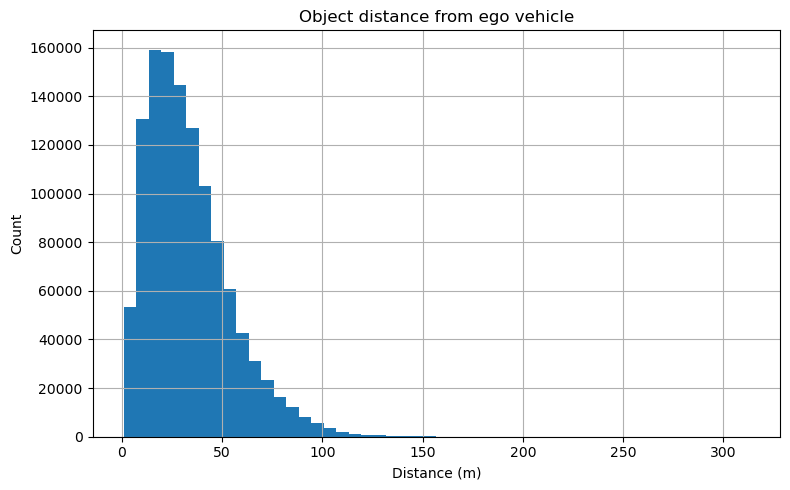

In [35]:
# Distance distribution
plt.figure(figsize=(8, 5))
raw_eda_df["distance_ego_2d"].hist(bins=50)
plt.title("Object distance from ego vehicle")
plt.xlabel("Distance (m)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

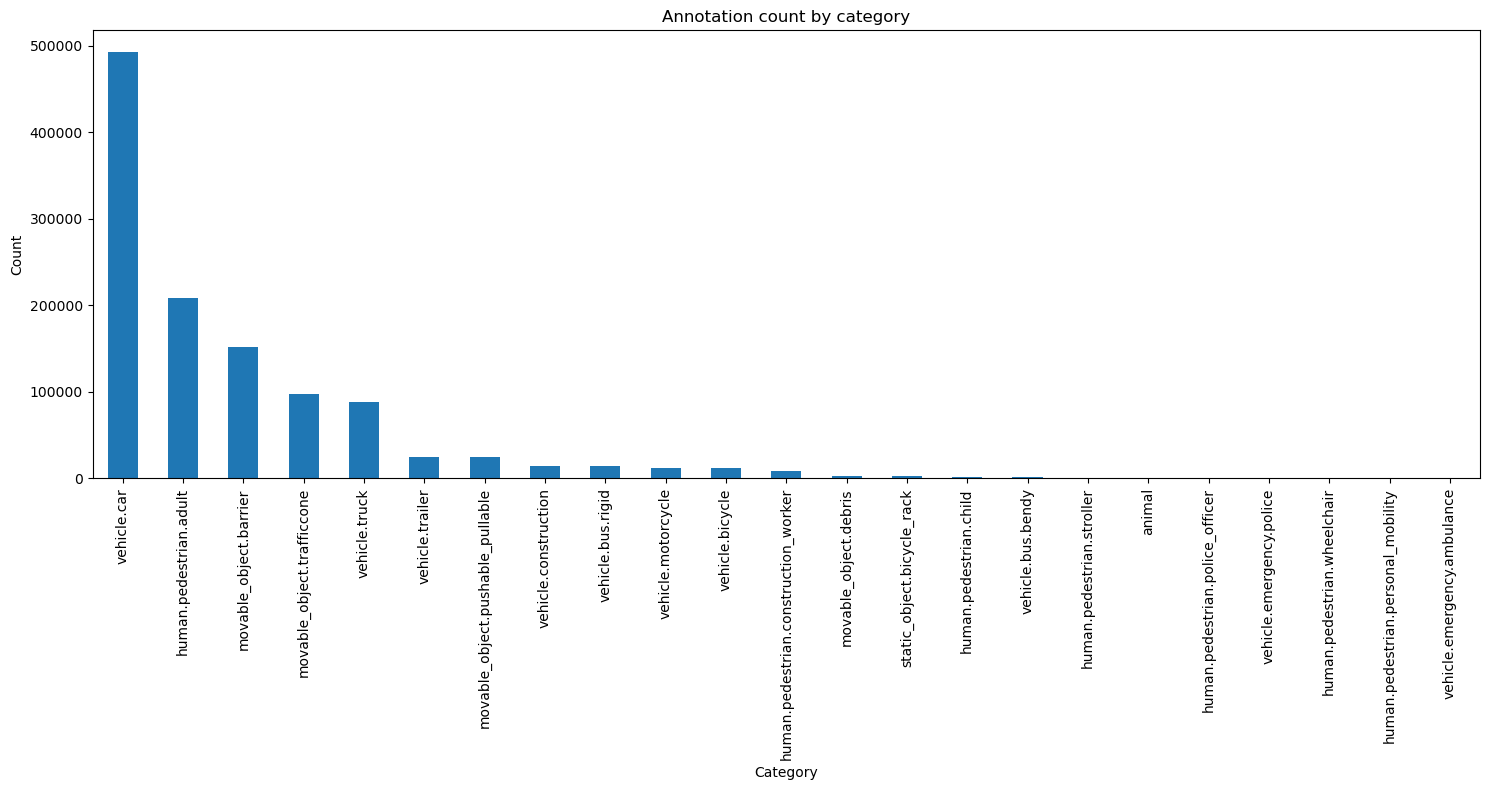

In [36]:
# Annotation count by category before filtering
raw_class_counts: pd.Series = (
    raw_eda_df["category_name"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(15, 8))
raw_class_counts.plot(kind="bar")
plt.title("Annotation count by category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## Clean the dataframe for statistical analysis

To avoid unstable results driven by extremely rare categories, categories with fewer than 30 annotations are removed from the statistical analysis.

In [37]:
# Keep only categories with at least 30 annotations
min_count: int = 30

raw_class_counts: pd.Series = raw_eda_df["category_name"].value_counts()

kept_categories = raw_class_counts[raw_class_counts >= min_count].index
removed_categories = raw_class_counts[raw_class_counts < min_count].index

category_filter_summary: pd.DataFrame = pd.DataFrame({
    "category_name": raw_class_counts.index,
    "count": raw_class_counts.values,
    "kept_for_analysis": raw_class_counts.values >= min_count,
})

# Check the condition
category_filter_summary

,category_name,count,kept_for_analysis
0,vehicle.car,493322,True
1,human.pedestrian.adult,208240,True
2,movable_object.barrier,152087,True
3,movable_object.trafficcone,97959,True
4,vehicle.truck,88519,True
5,vehicle.trailer,24860,True
6,movable_object.pushable_pullable,24605,True
7,vehicle.construction,14671,True
8,vehicle.bus.rigid,14501,True
9,vehicle.motorcycle,12617,True


In [38]:
# Working copy for EDA
eda_df: pd.DataFrame = raw_eda_df[
    raw_eda_df["category_name"].isin(kept_categories)
].copy()

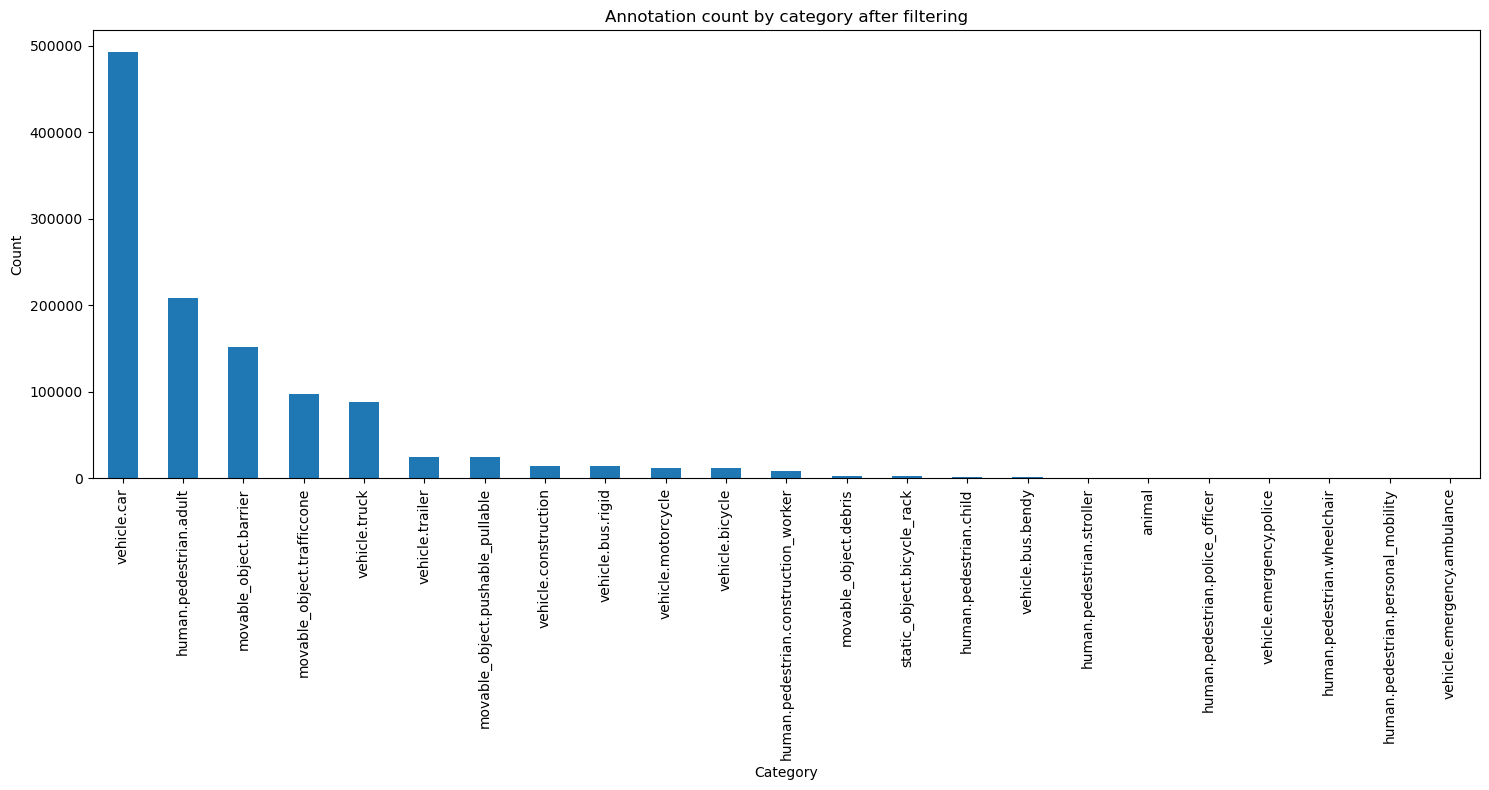

In [39]:
# Annotation count by category after filtering
eda_class_counts: pd.Series = (
    eda_df["category_name"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(15, 8))
eda_class_counts.plot(kind="bar")
plt.title("Annotation count by category after filtering")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

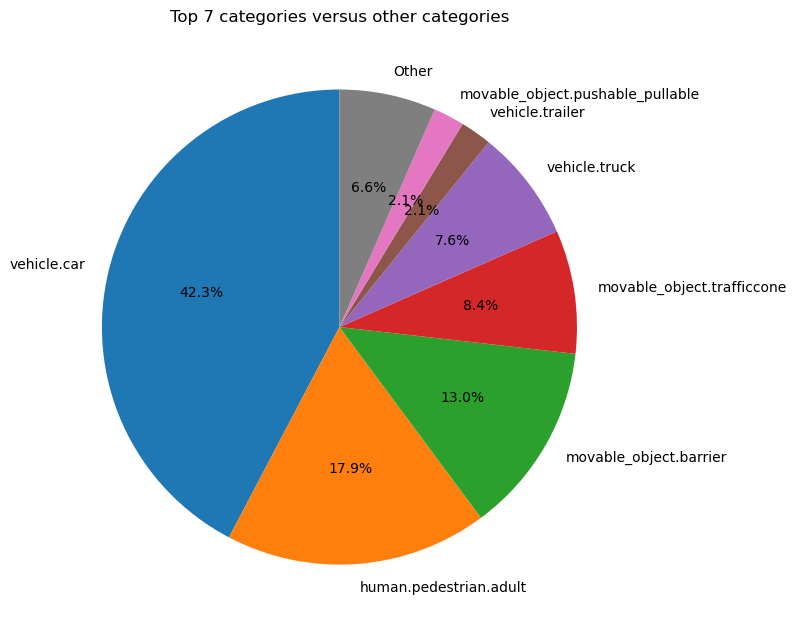

Categories included in 'Other':
['vehicle.construction', 'vehicle.bus.rigid', 'vehicle.motorcycle', 'vehicle.bicycle', 'human.pedestrian.construction_worker', 'movable_object.debris', 'static_object.bicycle_rack', 'human.pedestrian.child', 'vehicle.bus.bendy', 'human.pedestrian.stroller', 'animal', 'human.pedestrian.police_officer', 'vehicle.emergency.police', 'human.pedestrian.wheelchair', 'human.pedestrian.personal_mobility', 'vehicle.emergency.ambulance']


In [40]:
# Top categories versus the remaining long tail
top_n: int = 7

top_counts: pd.Series = eda_class_counts.iloc[:top_n]
other_count: int = int(eda_class_counts.iloc[top_n:].sum())

pie_counts: pd.Series = top_counts.copy()
pie_counts["Other"] = other_count

other_categories: pd.Series = eda_class_counts.iloc[top_n:]

plt.figure(figsize=(8, 8))
plt.pie(
    pie_counts.values,
    labels=pie_counts.index,
    autopct="%1.1f%%",
    startangle=90,
)
plt.title(f"Top {top_n} categories versus other categories")
plt.tight_layout()
plt.show()

print("Categories included in 'Other':")
print(list(other_categories.index))

## Observations

- To complete after reviewing the final class distribution plots.
- Key points to assess:
  - degree of class imbalance
  - presence of a long tail of rare categories
  - whether the filtering threshold removes only marginal classes or affects meaningful analysis groups

## Intrinsic object difficulty

This subsection examines whether some object categories are inherently more difficult to detect because of their physical properties and visibility, independently of sensor support.

The analysis focuses on:

- object dimensions by category
- object volume by category
- object aspect ratio by category
- object visibility by category
- compound hard-category patterns

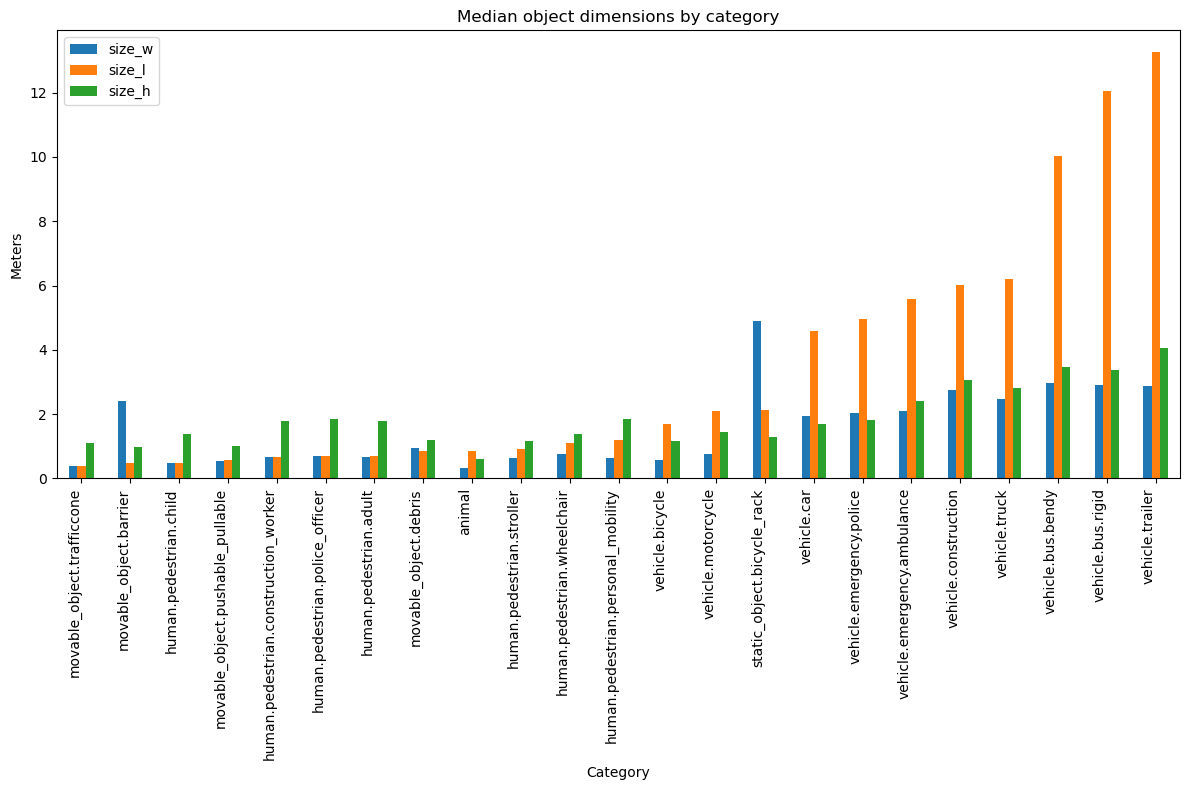

In [41]:
def plot_median_size_by_category(df: pd.DataFrame) -> None:
    """
    Plot median object width, length, and height by category.
    """
    median_sizes: pd.DataFrame = (
        df.groupby("category_name")[["size_w", "size_l", "size_h"]]
        .median()
        .sort_values("size_l")
    )

    median_sizes.plot(kind="bar", figsize=(12, 8))
    plt.title("Median object dimensions by category")
    plt.xlabel("Category")
    plt.ylabel("Meters")
    plt.xticks(rotation=90, ha="right")
    plt.tight_layout()
    plt.show()
    
plot_median_size_by_category(eda_df)

### Object volume by category

Object volume helps identify categories that are physically small and may therefore be harder to detect reliably.

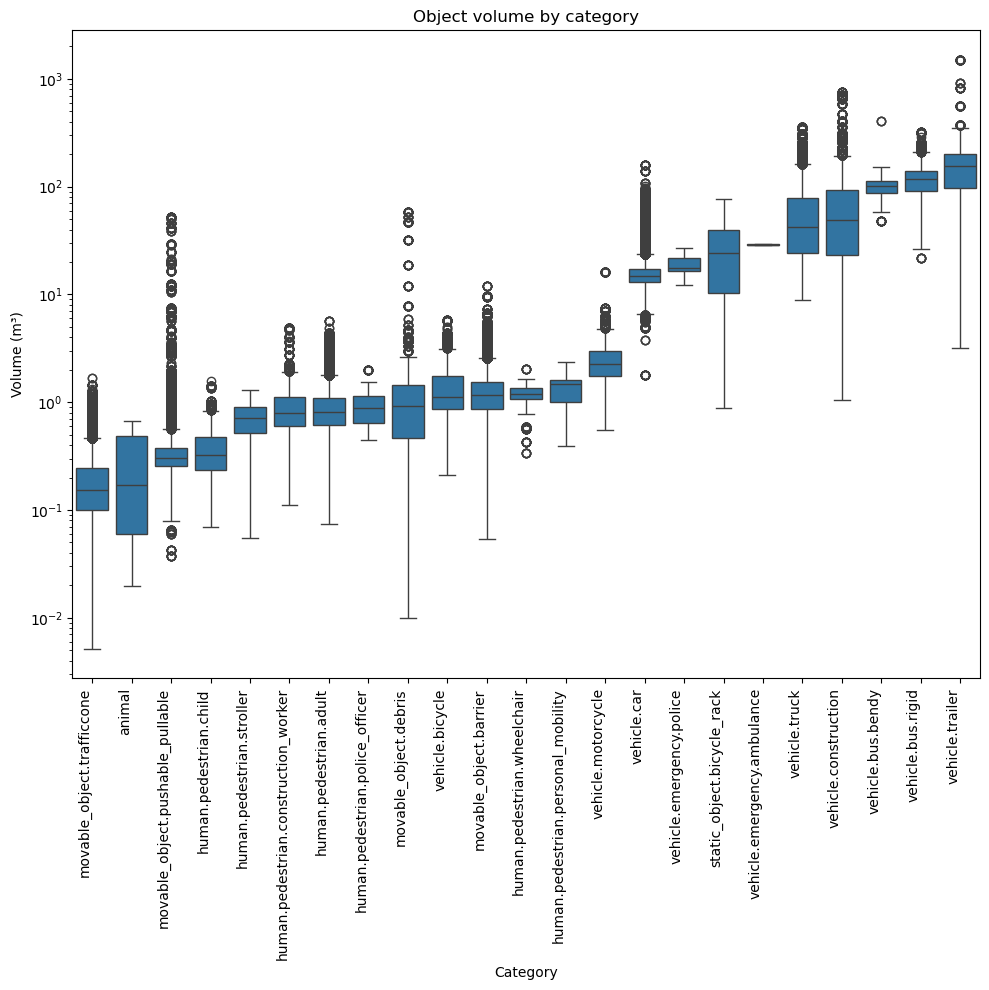

In [42]:
def plot_box_by_category(
    df: pd.DataFrame,
    y_col: str,
    title: str,
    ylabel: str,
    x_col: str = "category_name",
    figsize: Tuple[int, int] = (10, 10),
    order_by_median: bool = True,
    log_scale: bool = False,
    rotate_xticks: int = 90,
) -> None:
    """
    Plot the distribution of a numeric feature by category.
    """
    plot_df: pd.DataFrame = df.dropna(subset=[x_col, y_col]).copy()

    order = None
    if order_by_median:
        order = (
            plot_df.groupby(x_col)[y_col]
            .median()
            .sort_values()
            .index
        )

    plt.figure(figsize=figsize)
    sns.boxplot(
        data=plot_df,
        x=x_col,
        y=y_col,
        order=order,
    )

    plt.title(title)
    plt.xlabel("Category")
    plt.ylabel(ylabel)
    plt.xticks(rotation=rotate_xticks, ha="right")

    if log_scale:
        plt.yscale("log")

    plt.tight_layout()
    plt.show()
    
plot_box_by_category(
    df=eda_df,
    y_col="volume",
    title="Object volume by category",
    ylabel="Volume (m³)",
    log_scale=True,
)

In [43]:
def get_low_classes_by_median(
    df: pd.DataFrame,
    value_col: str,
    threshold: float,
    category_col: str = "category_name",
) -> pd.DataFrame:
    """
    Return categories whose median value is below a specified threshold.
    """
    summary_df: pd.DataFrame = (
        df.dropna(subset=[category_col, value_col])
        .groupby(category_col)[value_col]
        .median()
        .sort_values()
        .reset_index()
    )

    summary_df.columns = [category_col, f"median_{value_col}"]

    return summary_df.loc[summary_df[f"median_{value_col}"] < threshold].copy()

low_volume_df: pd.DataFrame = get_low_classes_by_median(
    df=eda_df,
    value_col="volume",
    threshold=1.0,
)

low_volume_df

,category_name,median_volume
0,movable_object.trafficcone,0.152942
1,animal,0.169413
2,movable_object.pushable_pullable,0.300613
3,human.pedestrian.child,0.324830
4,human.pedestrian.stroller,0.715726
5,human.pedestrian.construction_worker,0.796781
6,human.pedestrian.adult,0.810455
7,human.pedestrian.police_officer,0.882394
8,movable_object.debris,0.923709


### Object aspect ratio by category

Aspect ratio provides a simple proxy for object shape. Categories with more elongated or less compact shapes may be harder to localize consistently.

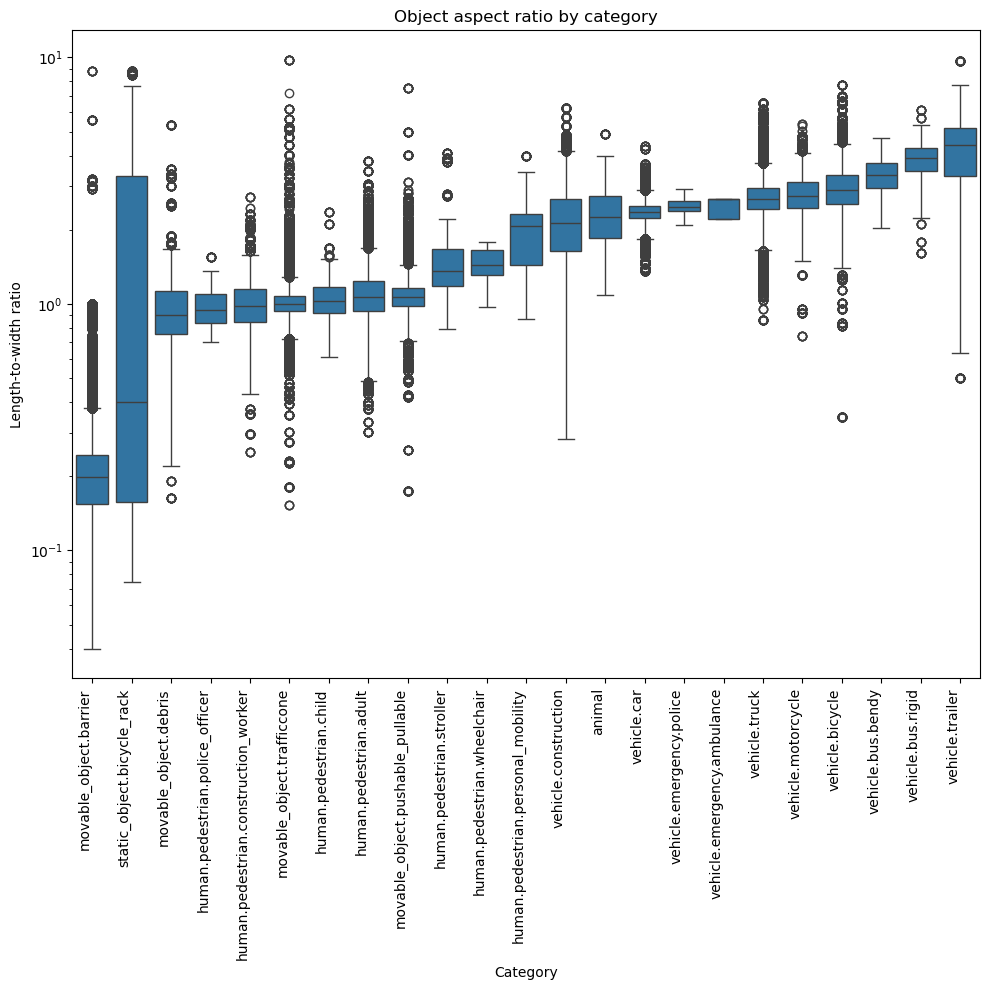

,category_name,median_aspect_ratio_l_w
0,movable_object.barrier,0.197678
1,static_object.bicycle_rack,0.400381
2,movable_object.debris,0.902874
3,human.pedestrian.police_officer,0.944223
4,human.pedestrian.construction_worker,0.984152


In [44]:
plot_box_by_category(
    df=eda_df,
    y_col="aspect_ratio_l_w",
    title="Object aspect ratio by category",
    ylabel="Length-to-width ratio",
    log_scale=True,
)

low_aspect_ratio_df: pd.DataFrame = get_low_classes_by_median(
    df=eda_df,
    value_col="aspect_ratio_l_w",
    threshold=1.0,
)

low_aspect_ratio_df

### Object visibility by category

Visibility is analyzed by category to identify object classes that are more frequently observed under low-visibility conditions.

In [45]:
vis_by_class: pd.DataFrame = (
    pd.crosstab(
        index=eda_df["category_name"],
        columns=eda_df["visibility_level"],
        normalize="index",
    )
    .sort_values("v0-40", ascending=False)
)

vis_by_class

visibility_level,v0-40,v40-60,v60-80,v80-100
category_name,,,,
human.pedestrian.stroller,0.495336,0.099813,0.097948,0.306903
vehicle.trailer,0.386484,0.134031,0.144006,0.335479
human.pedestrian.child,0.378025,0.097289,0.195547,0.329138
vehicle.construction,0.353759,0.146820,0.186695,0.312726
vehicle.car,0.320126,0.130128,0.142894,0.406852
human.pedestrian.adult,0.301138,0.108375,0.120496,0.469991
vehicle.motorcycle,0.273678,0.081715,0.111675,0.532932
vehicle.truck,0.271298,0.134265,0.180504,0.413934
human.pedestrian.construction_worker,0.267220,0.146600,0.155878,0.430302


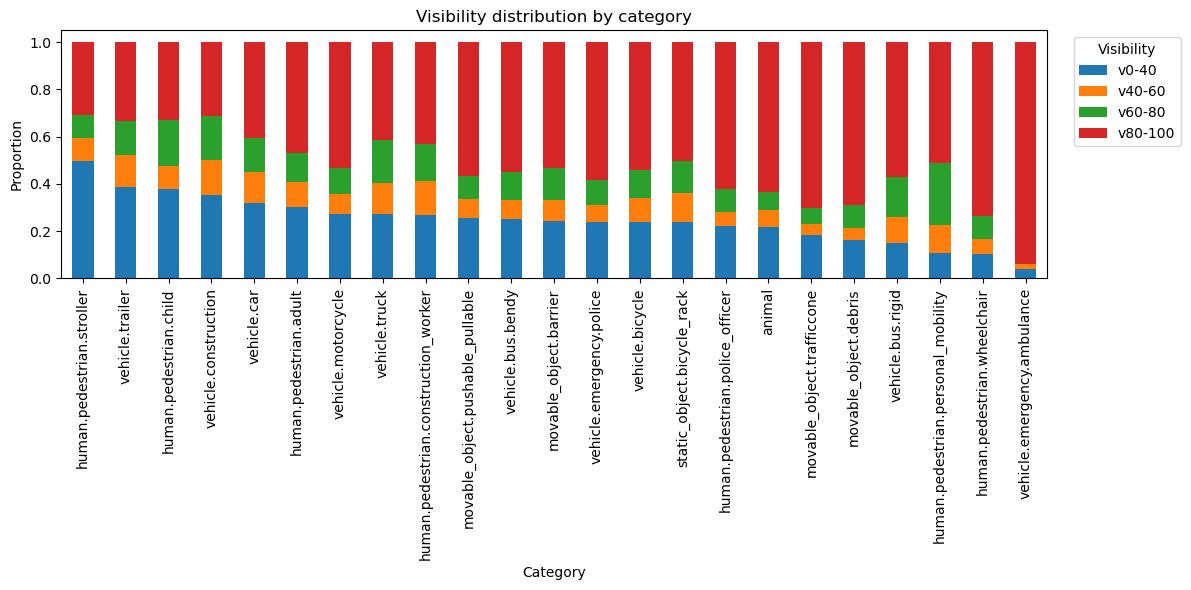

In [46]:
vis_by_class.plot(kind="bar", stacked=True, figsize=(12, 6))
plt.title("Visibility distribution by category")
plt.xlabel("Category")
plt.ylabel("Proportion")
plt.legend(title="Visibility", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [47]:
low_visibility_df: pd.DataFrame = vis_by_class.loc[vis_by_class["v0-40"] > 0.25].copy()
low_visibility_df

visibility_level,v0-40,v40-60,v60-80,v80-100
category_name,,,,
human.pedestrian.stroller,0.495336,0.099813,0.097948,0.306903
vehicle.trailer,0.386484,0.134031,0.144006,0.335479
human.pedestrian.child,0.378025,0.097289,0.195547,0.329138
vehicle.construction,0.353759,0.146820,0.186695,0.312726
vehicle.car,0.320126,0.130128,0.142894,0.406852
human.pedestrian.adult,0.301138,0.108375,0.120496,0.469991
vehicle.motorcycle,0.273678,0.081715,0.111675,0.532932
vehicle.truck,0.271298,0.134265,0.180504,0.413934
human.pedestrian.construction_worker,0.267220,0.146600,0.155878,0.430302


### Hard categories summary

The previous indicators are combined to identify categories that appear difficult across multiple intrinsic dimensions.

In [48]:
low_visibility_set = set(low_visibility_df.index)
low_aspect_ratio_set = set(low_aspect_ratio_df["category_name"])
low_volume_set = set(low_volume_df["category_name"])

In [49]:
category_intrinsic_flags: pd.DataFrame = pd.DataFrame({
    "category_name": sorted(eda_df["category_name"].unique()),
})

category_intrinsic_flags["low_visibility"] = (
    category_intrinsic_flags["category_name"].isin(low_visibility_set)
)
category_intrinsic_flags["low_aspect_ratio"] = (
    category_intrinsic_flags["category_name"].isin(low_aspect_ratio_set)
)
category_intrinsic_flags["low_volume"] = (
    category_intrinsic_flags["category_name"].isin(low_volume_set)
)

category_intrinsic_flags["n_intrinsic_difficulty_flags"] = (
    category_intrinsic_flags[["low_visibility", "low_aspect_ratio", "low_volume"]]
    .sum(axis=1)
)

category_intrinsic_flags["hard_in_at_least_two"] = (
    category_intrinsic_flags["n_intrinsic_difficulty_flags"] >= 2
)

category_intrinsic_flags["hard_in_all_three"] = (
    category_intrinsic_flags["n_intrinsic_difficulty_flags"] == 3
)

category_intrinsic_flags = category_intrinsic_flags.sort_values(
    ["n_intrinsic_difficulty_flags", "category_name"],
    ascending=[False, True],
).reset_index(drop=True)

category_intrinsic_flags

,category_name,low_visibility,low_aspect_ratio,low_volume,n_intrinsic_difficulty_flags,hard_in_at_least_two,hard_in_all_three
0,human.pedestrian.construction_worker,True,True,True,3,True,True
1,human.pedestrian.adult,True,False,True,2,True,False
2,human.pedestrian.child,True,False,True,2,True,False
3,human.pedestrian.police_officer,False,True,True,2,True,False
4,human.pedestrian.stroller,True,False,True,2,True,False
5,movable_object.debris,False,True,True,2,True,False
6,movable_object.pushable_pullable,True,False,True,2,True,False
7,animal,False,False,True,1,False,False
8,movable_object.barrier,False,True,False,1,False,False
9,movable_object.trafficcone,False,False,True,1,False,False


In [50]:
hard_in_all_three = set(
    category_intrinsic_flags.loc[
        category_intrinsic_flags["hard_in_all_three"],
        "category_name",
    ]
)

print("Hard in all three:")
pprint(hard_in_all_three)

hard_in_at_least_two = set(
    category_intrinsic_flags.loc[
        category_intrinsic_flags["hard_in_at_least_two"],
        "category_name",
    ]
)

print("\nHard in at least two:")
pprint(hard_in_at_least_two)

Hard in all three:
{'human.pedestrian.construction_worker'}

Hard in at least two:
{'human.pedestrian.adult',
 'human.pedestrian.child',
 'human.pedestrian.construction_worker',
 'human.pedestrian.police_officer',
 'human.pedestrian.stroller',
 'movable_object.debris',
 'movable_object.pushable_pullable'}


In [51]:
print("Low visibility + low aspect ratio:")
print(low_visibility_set & low_aspect_ratio_set)

print("\nLow visibility + low volume:")
print(low_visibility_set & low_volume_set)

print("\nLow aspect ratio + low volume:")
print(low_aspect_ratio_set & low_volume_set)

Low visibility + low aspect ratio:
{'human.pedestrian.construction_worker'}

Low visibility + low volume:
{'human.pedestrian.child', 'movable_object.pushable_pullable', 'human.pedestrian.adult', 'human.pedestrian.stroller', 'human.pedestrian.construction_worker'}

Low aspect ratio + low volume:
{'movable_object.debris', 'human.pedestrian.construction_worker', 'human.pedestrian.police_officer'}


In [52]:
hard_rows: int = int(
    eda_df[eda_df["category_name"].isin(hard_in_at_least_two)].shape[0]
)
all_rows: int = int(eda_df.shape[0])

print("Intrinsic hard categories:")
print(sorted(hard_in_at_least_two))

print(f"\nPercentage of rows from hard categories: {100 * hard_rows / all_rows:.2f}%")

Intrinsic hard categories:
['human.pedestrian.adult', 'human.pedestrian.child', 'human.pedestrian.construction_worker', 'human.pedestrian.police_officer', 'human.pedestrian.stroller', 'movable_object.debris', 'movable_object.pushable_pullable']

Percentage of rows from hard categories: 21.34%


### Observations

- To complete after validating the final plots and thresholds.
- Key points to summarize:
  - which categories are consistently small, thin, or poorly visible
  - whether intrinsic difficulty is concentrated in a few categories
  - whether intrinsically hard categories account for a meaningful share of annotations

**Conclusion template:**  
Overall, intrinsic difficulty is concentrated in a small number of categories whose object size, shape, and visibility make them systematically harder to detect, suggesting that later fusion analysis should pay particular attention to these classes.

## Sensor reliability by regime

This section characterizes the reliability of each sensing modality across distance, visibility, and object category. The goal is to identify where each sensor is informative, weak, or absent before moving to fusion complementarity.

### Helper functions

In [118]:
def summarize_flag_by_group(
    df: pd.DataFrame,
    group_col: str,
    flag_col: str,
    sort_index: bool = True,
) -> pd.DataFrame:
    """
    Return the within-group proportion of False/True values for a boolean flag.
    """
    table: pd.DataFrame = pd.crosstab(
        index=df[group_col],
        columns=df[flag_col],
        normalize="index",
    )

    if sort_index:
        table = table.sort_index()

    return table 

def plot_stacked_proportion_table(
    table: pd.DataFrame,
    title: str,
    xlabel: str,
    ylabel: str = "Proportion",
    figsize: Tuple[int, int] = (8, 4),
    rot: int = 0,
    ha: str = "center",
) -> None:
    """
    Plot a stacked bar chart from a summary table of proportions.
    Rows are groups, columns are mutually exclusive categories.
    """
    ax = table.plot(
        kind="bar",
        stacked=True,
        figsize=figsize,
    )

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=rot, ha=ha)

    ax.legend(
        title="Support level",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        borderaxespad=0,
    )

    plt.tight_layout()
    plt.show()
    
def plot_bar_from_table(
    table: pd.DataFrame,
    true_col: bool = True,
    title: str = "",
    ylabel: str = "",
    xlabel: str = "",
    figsize: Tuple[int, int] = (8, 4),
    rot: int = 0,
    ha: str = "center",
) -> None:
    """
    Plot the proportion associated with the True column from a boolean summary table.
    """
    plot_series: pd.Series = table[true_col] if true_col in table.columns else pd.Series(0, index=table.index)

    ax = plot_series.plot.bar(figsize=figsize, title=title, rot=rot)
    ax.set_ylabel(ylabel)
    ax.set_xlabel(xlabel)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=rot, ha=ha)
    plt.tight_layout()
    plt.show()
    
def make_support_summary_table(
    df: pd.DataFrame,
    group_col: str,
    flag_cols: List[str],
) -> pd.DataFrame:
    """
    Return the percentage of annotations in each boolean support group by regime.
    """
    summary_df: pd.DataFrame = (
        df.groupby(group_col)[flag_cols]
        .mean()
        .mul(100)
        .round(1)
    )
    return summary_df

### Camera reliability

In [119]:
camera_flags: Dict[str, str] = {
    "weak_camera_view": "Weak camera view",
    "limited_camera_view": "Limited camera view",
    "good_camera_view": "Good camera view",
}

#### Camera reliability by distance

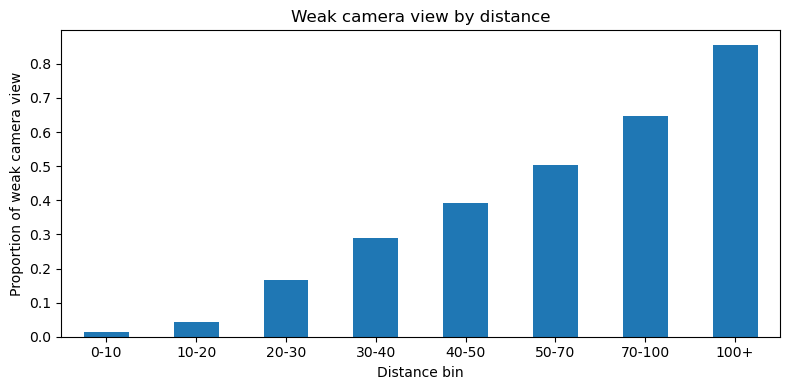

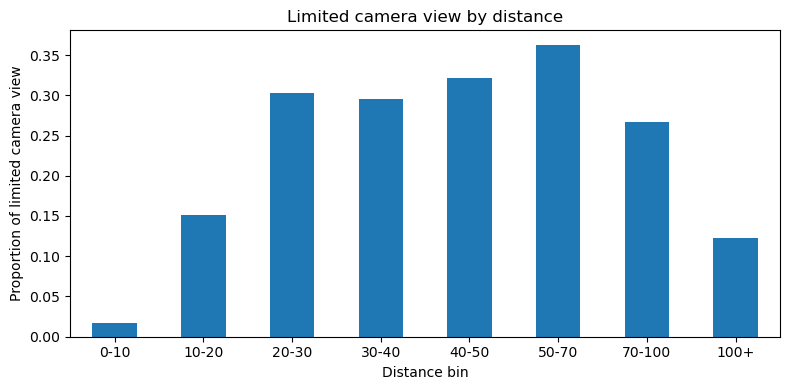

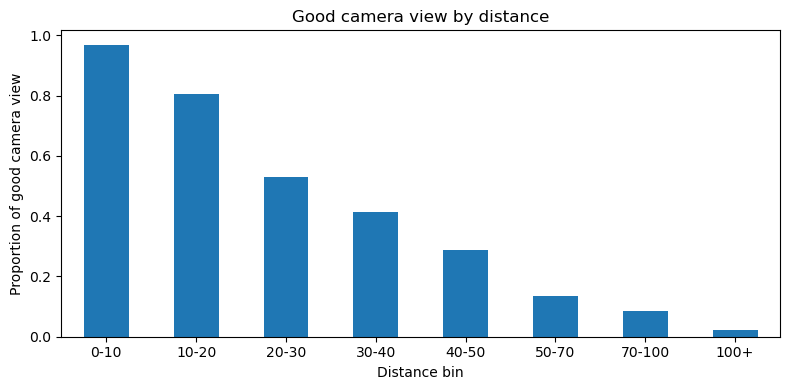

In [120]:
for flag, label in camera_flags.items():
    table: pd.DataFrame = summarize_flag_by_group(eda_df, "distance_bin", flag)

    plot_bar_from_table(
        table=table,
        title=f"{label} by distance",
        ylabel=f"Proportion of {label.lower()}",
        xlabel="Distance bin",
    )

#### Camera reliability by visibility

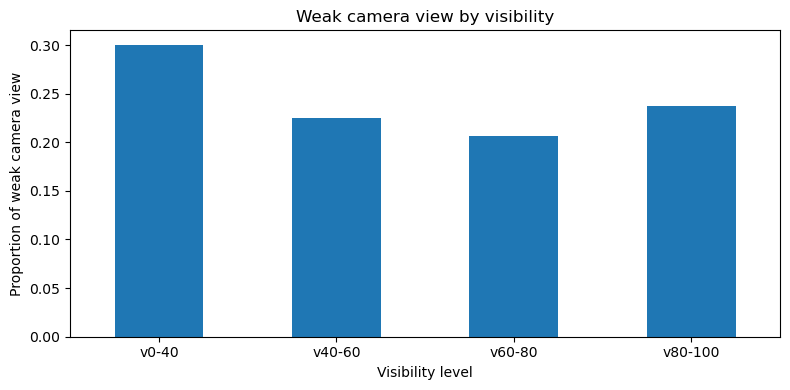

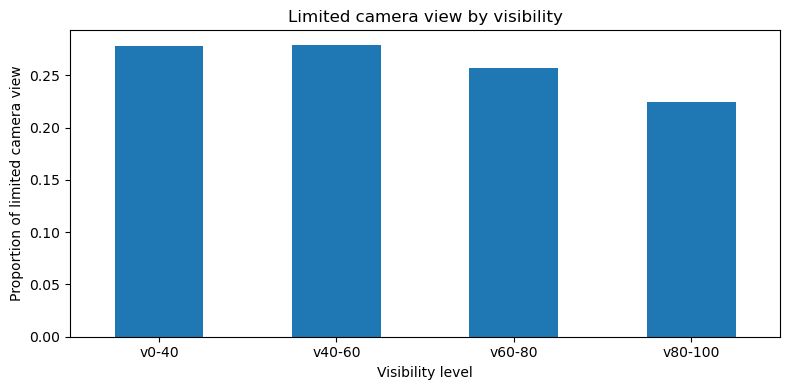

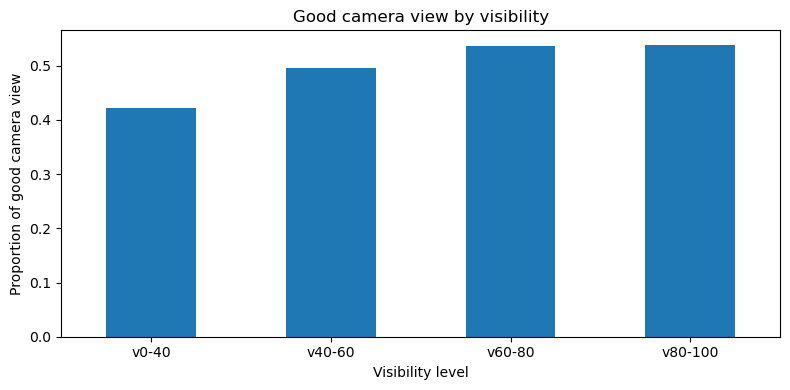

In [59]:
for flag, label in camera_flags.items():
    table: pd.DataFrame = summarize_flag_by_group(eda_df, "visibility_level", flag)

    plot_bar_from_table(
        table=table,
        title=f"{label} by visibility",
        ylabel=f"Proportion of {label.lower()}",
        xlabel="Visibility level",
    )

#### Camera reliability by category

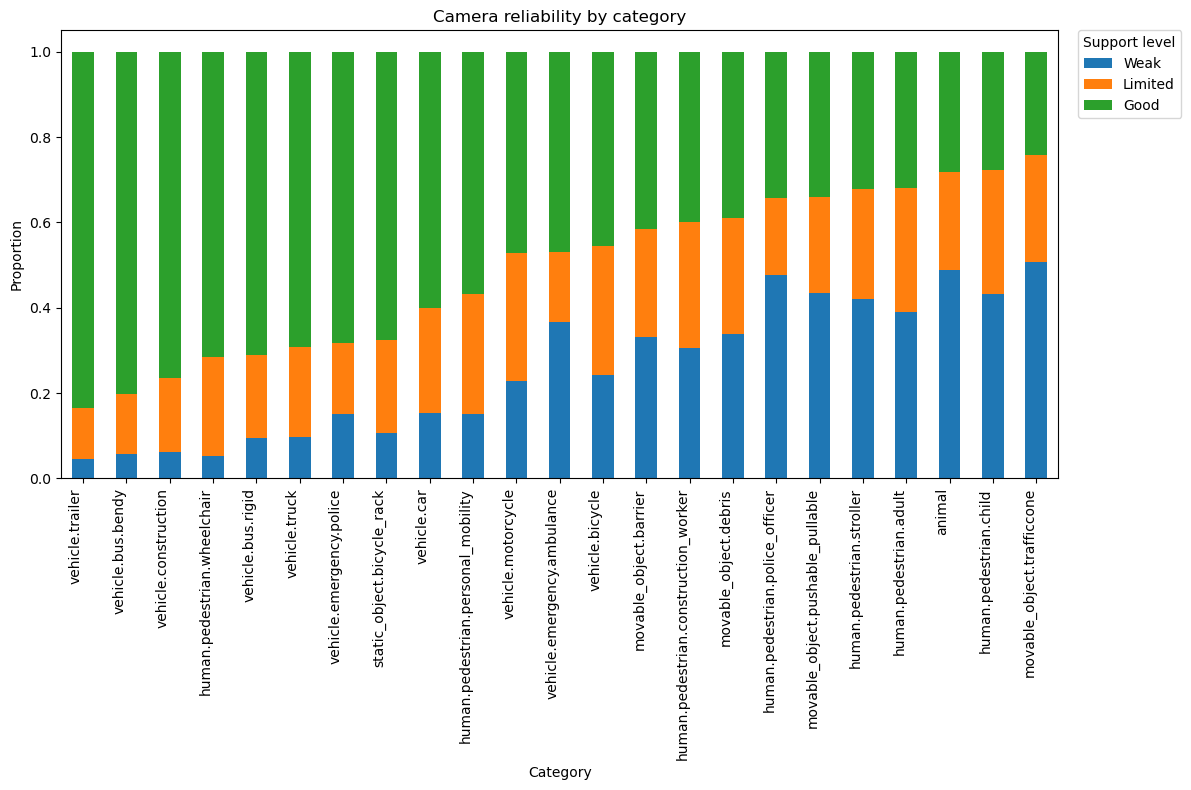

In [60]:
camera_by_category: pd.DataFrame = (
    eda_df.groupby("category_name")[
        ["weak_camera_view", "limited_camera_view", "good_camera_view"]
    ]
    .mean()
    .rename(columns={
        "weak_camera_view": "Weak",
        "limited_camera_view": "Limited",
        "good_camera_view": "Good",
    })
    .sort_values("Good", ascending=False)
)

plot_stacked_proportion_table(
    table=camera_by_category,
    title="Camera reliability by category",
    xlabel="Category",
    figsize=(12, 8),
    rot=90,
    ha="right",
)

#### Camera summary tables

In [121]:
camera_support_summary_by_distance: pd.DataFrame = make_support_summary_table(
    eda_df,
    "distance_bin",
    ["weak_camera_view", "limited_camera_view", "good_camera_view"],
)

camera_support_summary_by_distance

,weak_camera_view,limited_camera_view,good_camera_view
distance_bin,,,
0-10,1.4,1.8,96.8
10-20,4.2,15.2,80.6
20-30,16.7,30.3,53.0
30-40,29.0,29.5,41.5
40-50,39.2,32.1,28.7
50-70,50.2,36.3,13.5
70-100,64.8,26.7,8.5
100+,85.5,12.2,2.2


In [62]:
camera_support_summary_by_distance: pd.DataFrame = make_support_summary_table(
    eda_df,
    "distance_bin",
    ["weak_camera_view", "limited_camera_view", "good_camera_view"],
)

camera_support_summary_by_distance

,weak_camera_view,limited_camera_view,good_camera_view
distance_bin,,,
0-10,1.4,1.8,96.8
10-20,4.2,15.2,80.6
20-30,16.7,30.3,53.0
30-40,29.0,29.5,41.5
40-50,39.2,32.1,28.7
50-70,50.2,36.3,13.5
70-100,64.8,26.7,8.5
100+,85.5,12.2,2.2


### LiDAR reliability

In [63]:
lidar_flags: Dict[str, str] = {
    "no_lidar_support": "No LiDAR support",
    "low_lidar_support": "Low LiDAR support",
    "usable_lidar_support": "Usable LiDAR support",
}

#### LiDAR reliability by distance

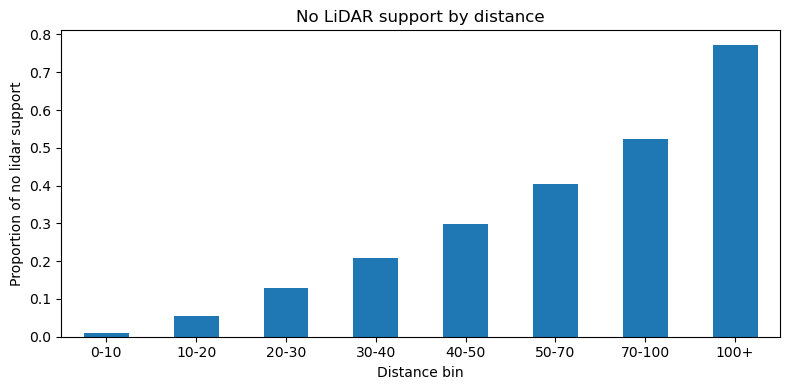

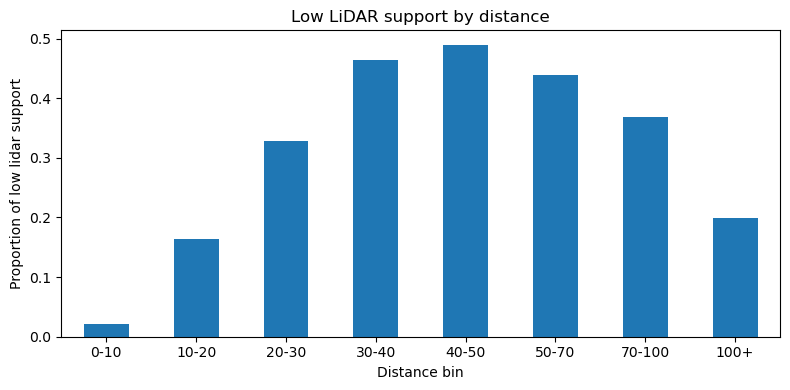

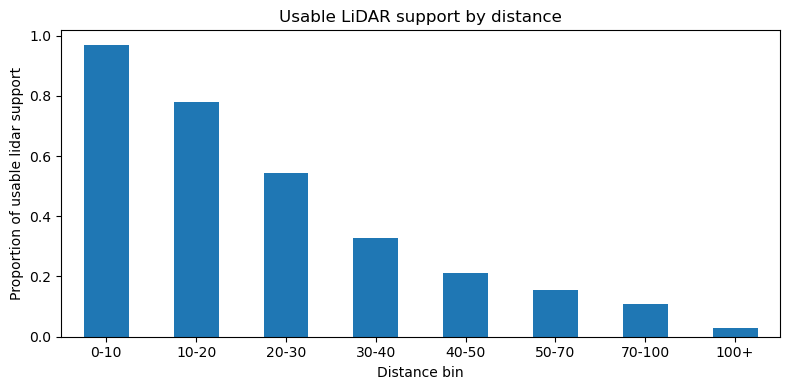

In [64]:
for flag, label in lidar_flags.items():
    table: pd.DataFrame = summarize_flag_by_group(eda_df, "distance_bin", flag)

    plot_bar_from_table(
        table=table,
        title=f"{label} by distance",
        ylabel=f"Proportion of {label.lower()}",
        xlabel="Distance bin",
    )

#### LiDAR reliability by visibility

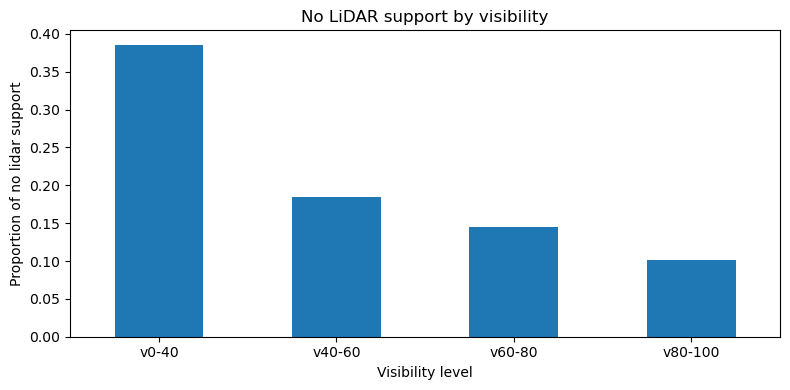

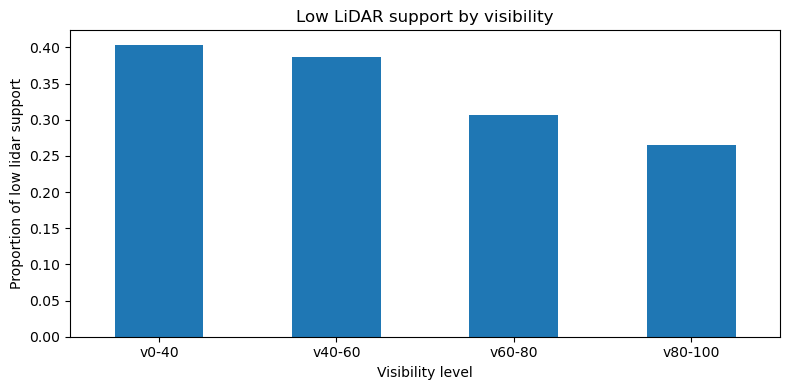

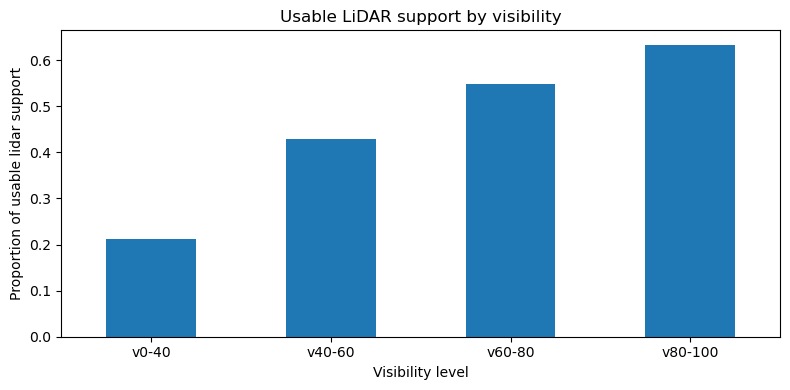

In [65]:
for flag, label in lidar_flags.items():
    table: pd.DataFrame = summarize_flag_by_group(eda_df, "visibility_level", flag)

    plot_bar_from_table(
        table=table,
        title=f"{label} by visibility",
        ylabel=f"Proportion of {label.lower()}",
        xlabel="Visibility level",
    )

#### LiDAR reliability by category

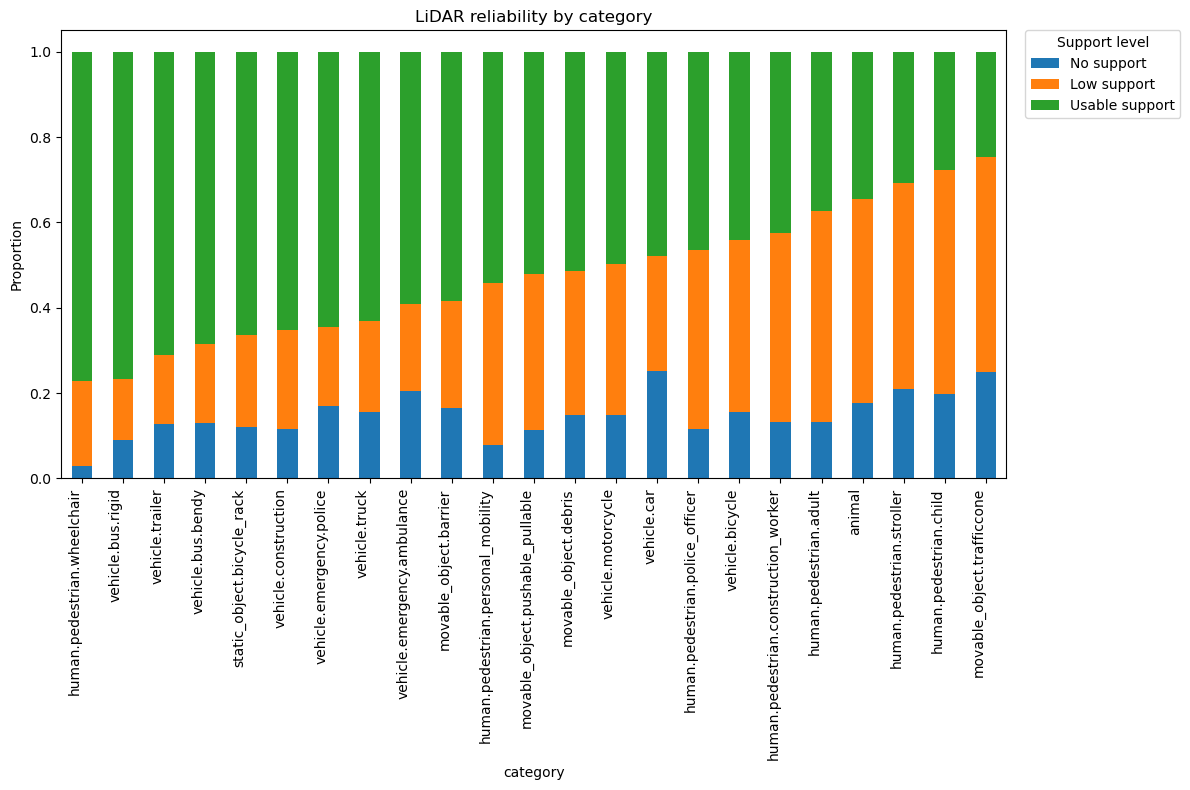

In [66]:
lidar_by_distance: pd.DataFrame = (
    eda_df.groupby("category_name")[
        ["no_lidar_support", "low_lidar_support", "usable_lidar_support"]
    ]
    .mean()
    .rename(columns={
        "no_lidar_support": "No support",
        "low_lidar_support": "Low support",
        "usable_lidar_support": "Usable support",
    })
    .sort_values("Usable support", ascending=False)
)

plot_stacked_proportion_table(
    table=lidar_by_distance,
    title="LiDAR reliability by category",
    xlabel="category",
    figsize=(12, 8),
    rot=90,
    ha="right",
)

#### LiDAR summary tables

In [67]:
lidar_support_summary_by_distance: pd.DataFrame = make_support_summary_table(
    eda_df,
    "distance_bin",
    ["no_lidar_support", "low_lidar_support", "usable_lidar_support"],
)

lidar_support_summary_by_distance

,no_lidar_support,low_lidar_support,usable_lidar_support
distance_bin,,,
0-10,0.9,2.2,96.9
10-20,5.6,16.3,78.1
20-30,12.8,32.8,54.5
30-40,20.7,46.5,32.8
40-50,29.9,48.9,21.2
50-70,40.3,44.0,15.7
70-100,52.3,36.8,10.9
100+,77.2,19.9,2.9


In [68]:
lidar_support_summary_by_visibility: pd.DataFrame = make_support_summary_table(
    eda_df,
    "visibility_level",
    ["no_lidar_support", "low_lidar_support", "usable_lidar_support"],
)

lidar_support_summary_by_visibility

,no_lidar_support,low_lidar_support,usable_lidar_support
visibility_level,,,
v0-40,38.6,40.3,21.1
v40-60,18.5,38.7,42.9
v60-80,14.5,30.7,54.8
v80-100,10.2,26.6,63.3


### Radar reliability

In [72]:
radar_flags: Dict[str, str] = {
    "no_radar_support": "No radar support",
    "low_radar_support": "Low radar support",
    "usable_radar_support": "Usable radar support",
}

#### Radar reliability by distance

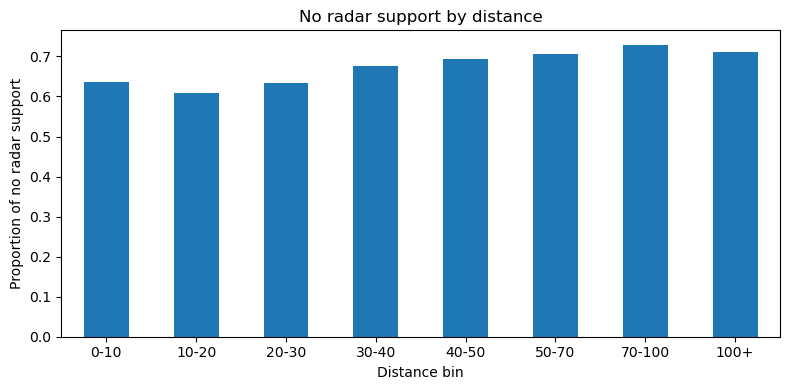

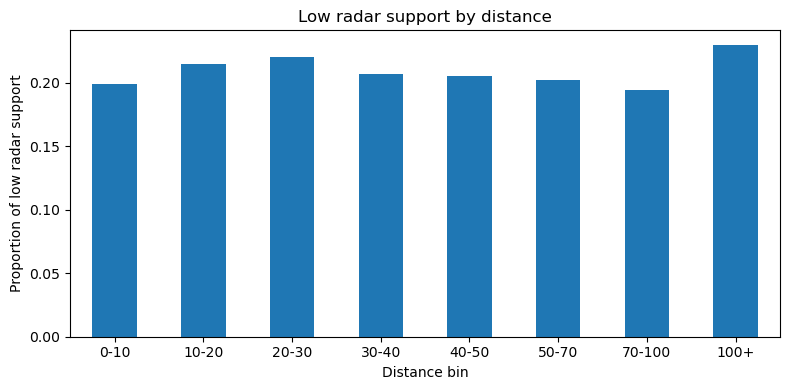

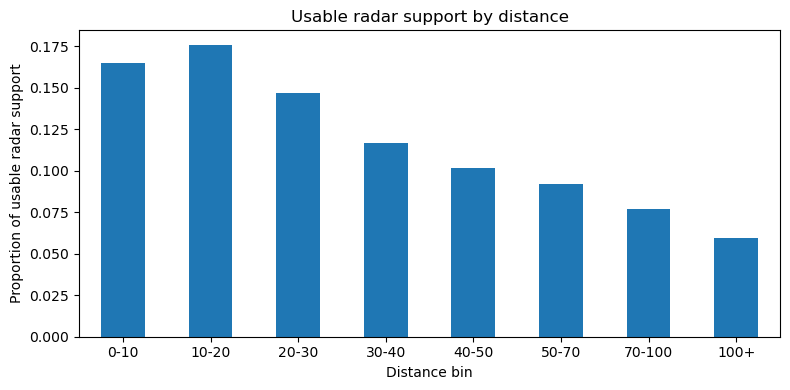

In [73]:
for flag, label in radar_flags.items():
    table: pd.DataFrame = summarize_flag_by_group(eda_df, "distance_bin", flag)

    plot_bar_from_table(
        table=table,
        title=f"{label} by distance",
        ylabel=f"Proportion of {label.lower()}",
        xlabel="Distance bin",
    )

#### Radar reliability by visibility

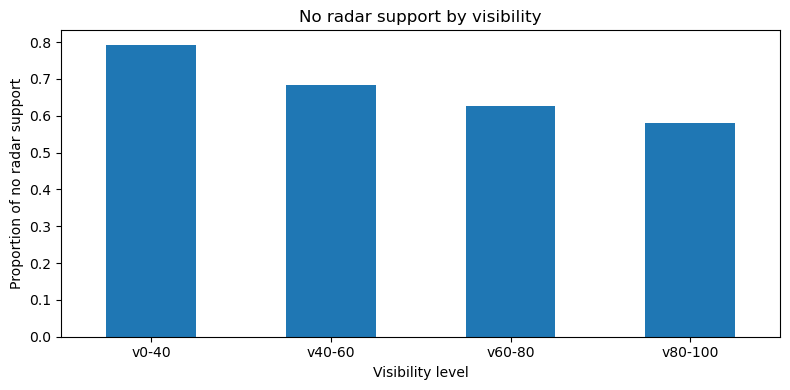

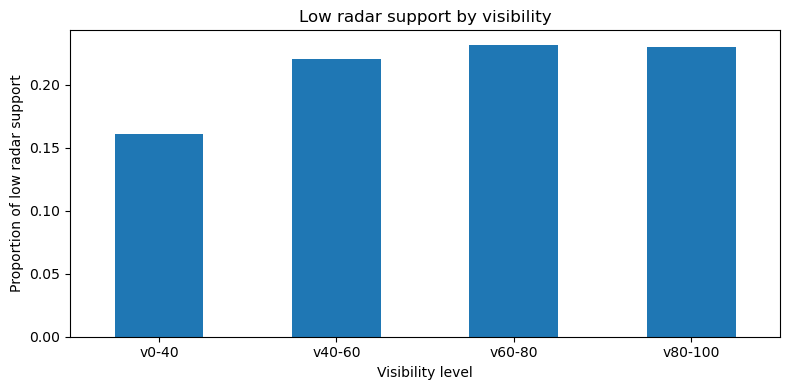

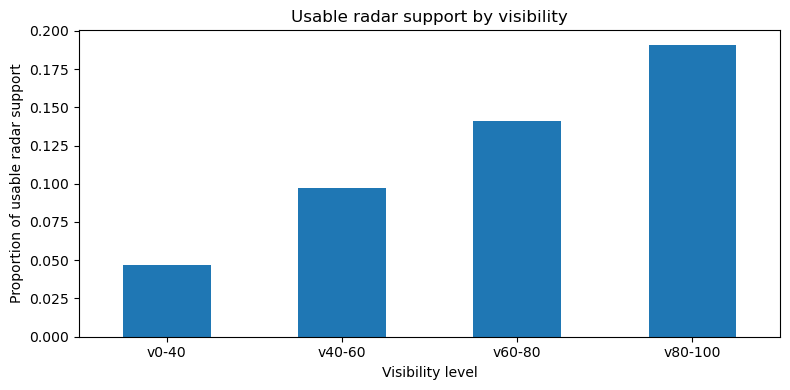

In [74]:
for flag, label in radar_flags.items():
    table: pd.DataFrame = summarize_flag_by_group(eda_df, "visibility_level", flag)

    plot_bar_from_table(
        table=table,
        title=f"{label} by visibility",
        ylabel=f"Proportion of {label.lower()}",
        xlabel="Visibility level",
    )

#### Radar reliability by category

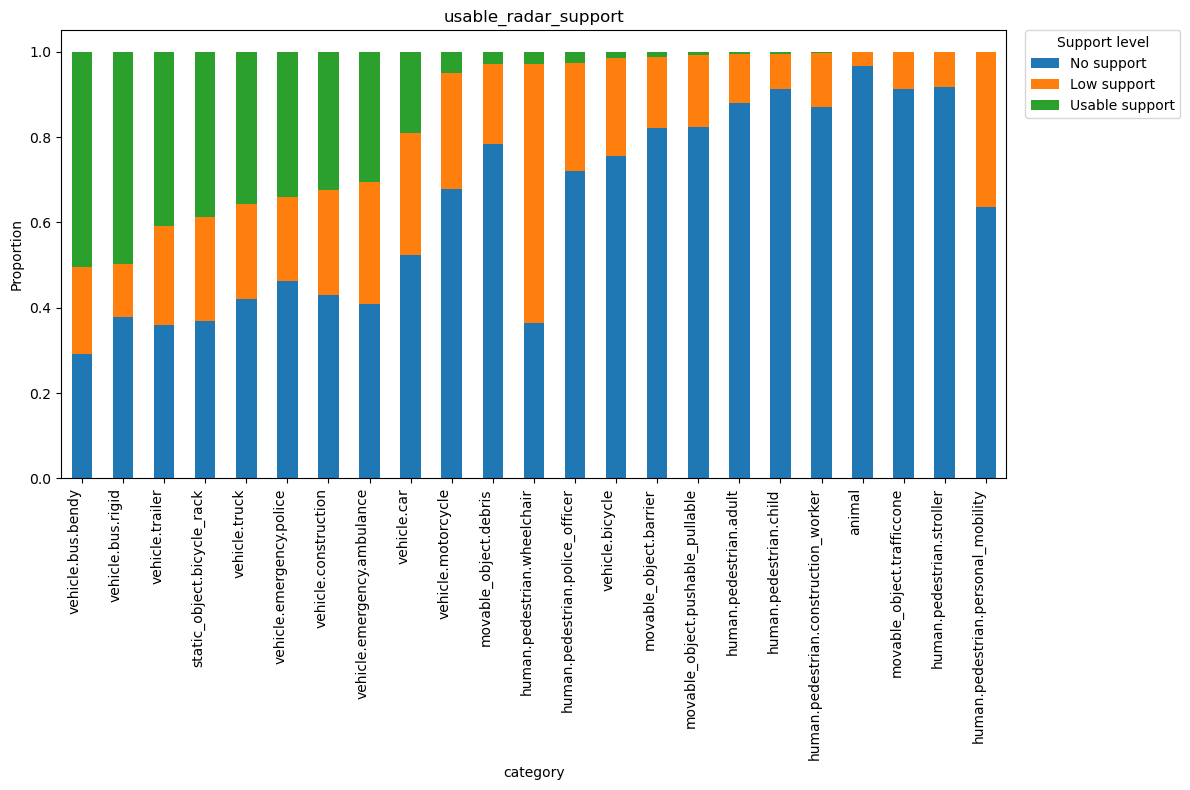

In [75]:
radar_by_distance: pd.DataFrame = (
    eda_df.groupby("category_name")[
        ["no_radar_support", "low_radar_support", "usable_radar_support"]
    ]
    .mean()
    .rename(columns={
        "no_radar_support": "No support",
        "low_radar_support": "Low support",
        "usable_radar_support": "Usable support",
    })
    .sort_values("Usable support", ascending=False)
)

plot_stacked_proportion_table(
    table=radar_by_distance,
    title="usable_radar_support",
    xlabel="category",
    figsize=(12, 8),
    rot=90,
    ha="right",
)


#### Radar summary tables

In [79]:
radar_support_summary_by_distance: pd.DataFrame = make_support_summary_table(
    eda_df,
    "distance_bin",
    ["no_radar_support", "low_radar_support", "usable_radar_support"],
)

radar_support_summary_by_distance

,no_radar_support,low_radar_support,usable_radar_support
distance_bin,,,
0-10,63.6,19.9,16.5
10-20,60.9,21.5,17.6
20-30,63.3,22.0,14.7
30-40,67.6,20.7,11.7
40-50,69.4,20.5,10.1
50-70,70.6,20.2,9.2
70-100,72.9,19.4,7.7
100+,71.1,23.0,5.9


In [80]:
radar_support_summary_by_visibility: pd.DataFrame = make_support_summary_table(
    eda_df,
    "visibility_level",
    ["no_radar_support", "low_radar_support", "usable_radar_support"],
)

radar_support_summary_by_visibility

,no_radar_support,low_radar_support,usable_radar_support
visibility_level,,,
v0-40,79.3,16.1,4.7
v40-60,68.2,22.0,9.7
v60-80,62.7,23.2,14.1
v80-100,57.9,23.0,19.1


#### Observations
What this section should conclude

This section should answer:

when camera is reliable
when LiDAR is reliable
when radar is available/useful
how these change with distance and visibility
Example key insights

Camera reliability

* Camera support is strongest in close to mid-range regimes and weakens as object distance increases.
* Camera quality is also sensitive to visibility, with weak-camera cases becoming more common under poorer visibility conditions.
* Categories with small image footprint are more likely to suffer from weak camera support.

LiDAR reliability

* LiDAR support is not uniformly strong; sparse or missing LiDAR occurs in non-trivial parts of the dataset.
* Low LiDAR support may behave more like missing LiDAR than like robust range support.
* LiDAR reliability changes with regime and should not be treated as constant.

Radar reliability

* Radar is often absent or sparse, so it should be viewed as a complementary modality rather than a universally available one.
* When present, radar may remain useful in regimes where camera support weakens, especially at longer range.


Strong concluding sentence template

Overall, sensor reliability is strongly regime-dependent: camera is typically strongest in more favorable visual conditions, while LiDAR and radar provide uneven but potentially valuable support depending on distance, visibility, and object class.

## Cross-modal complementarity

This section examines whether one sensing modality remains informative when another becomes weak or unavailable. The goal is to identify regimes where fusion is likely to provide real value beyond unimodal detection.

Rather than enumerating all possible combinations, I focus on a small set of interpretable regimes:
- camera rescues weak range sensing
- range sensing rescues weak camera
- all modalities are strong
- all modalities are weak

These regimes directly capture when fusion is beneficial.

In [198]:
# ------------------------------------------------------------
# One strong modality, two weak modalities
# ------------------------------------------------------------

eda_df["camera_strong_with_lidar_support"] = (
    eda_df["good_camera_view"]
    & ~eda_df["no_lidar_support"]
)

eda_df["camera_not_good_lidar_low"] = (
    ~eda_df["good_camera_view"]
    & eda_df["low_lidar_support"]
)

# eda_df["radar_only_strong"] = (
#     ~eda_df["good_camera_view"]
#     & ~eda_df["usable_lidar_support"]
#     & eda_df["usable_radar_support"]
# )

### Helper functions

In [199]:
def summarize_flags_by_group(
    df: pd.DataFrame,
    group_col: str,
    flag_cols: List[str]
) -> pd.DataFrame:
    """Return mean rate of boolean flags by group."""
    return (
        df.groupby(group_col)[flag_cols]
        .mean()
        .sort_index()
    )

def plot_grouped_flag_rates(
    table: pd.DataFrame,
    title: str,
    xlabel: str,
    ylabel: str = "Proportion",
    figsize: tuple = (10, 5),
    rot: int = 0
) -> None:
    """Plot grouped bar chart from grouped flag-rate table."""
    ax = table.plot(kind="bar", figsize=figsize)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    plt.xticks(rotation=rot)
    plt.legend(
        title="",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        borderaxespad=0
    )
    plt.tight_layout()
    plt.show()

def plot_flag_by_category(
    df: pd.DataFrame,
    flag_col: str,
    title: str,
    ylabel: str = "Proportion",
    xlabel: str = "Category",
    rot: int = 90,
    ascending: bool = False
) -> pd.DataFrame:
    """Plot mean per-category rate for one boolean flag."""
    table = (
        summarize_flags_by_group(
            df=df,
            group_col="category_name",
            flag_cols=[flag_col]
        )
        .sort_values(by=flag_col, ascending=ascending)
    )

    ax = table[flag_col].plot.bar(figsize=(12, 5), rot=rot)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    plt.xticks(rotation=rot, ha="right")
    plt.tight_layout()
    plt.show()

    return table

### Global prevalence of complementarity regimes

In [200]:
complementarity_flags = [
    "camera_strong_with_lidar_support",
    "camera_not_good_lidar_low",
]

complementarity_label_map = {
    "camera_strong_with_lidar_support": "Camera strong with LiDAR support",
    "camera_not_good_lidar_low": "Camera not good and LiDAR low",
}

complementarity_summary = (
    eda_df[complementarity_flags]
    .mean()
    .mul(100)
    .rename(index=complementarity_label_map)
    .sort_values(ascending=False)
    .round(2)
)

print("Camera–LiDAR regime prevalence (% of rows):")
print(complementarity_summary)

Camera–LiDAR regime prevalence (% of rows):
Camera strong with LiDAR support    45.50
Camera not good and LiDAR low       24.75
dtype: float64


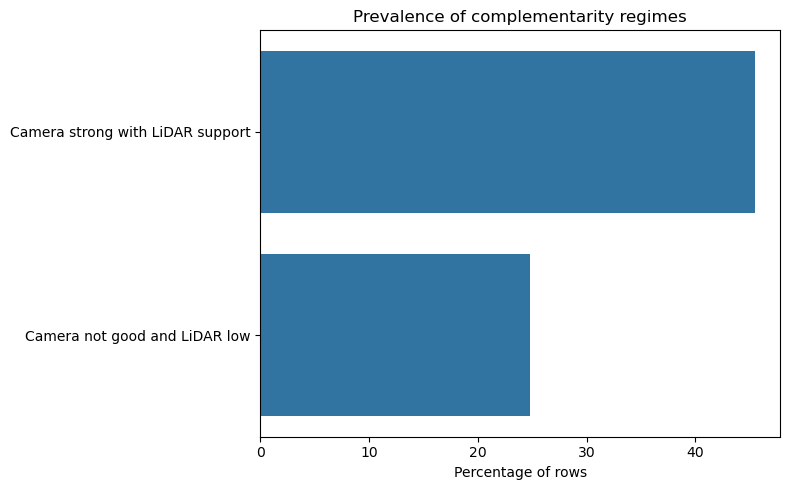

In [201]:
plt.figure(figsize=(8, 5))
sns.barplot(
    x=complementarity_summary.values,
    y=complementarity_summary.index
)
plt.title("Prevalence of complementarity regimes")
plt.xlabel("Percentage of rows")
plt.ylabel("")
plt.tight_layout()
plt.show()

### Complementarity by distance

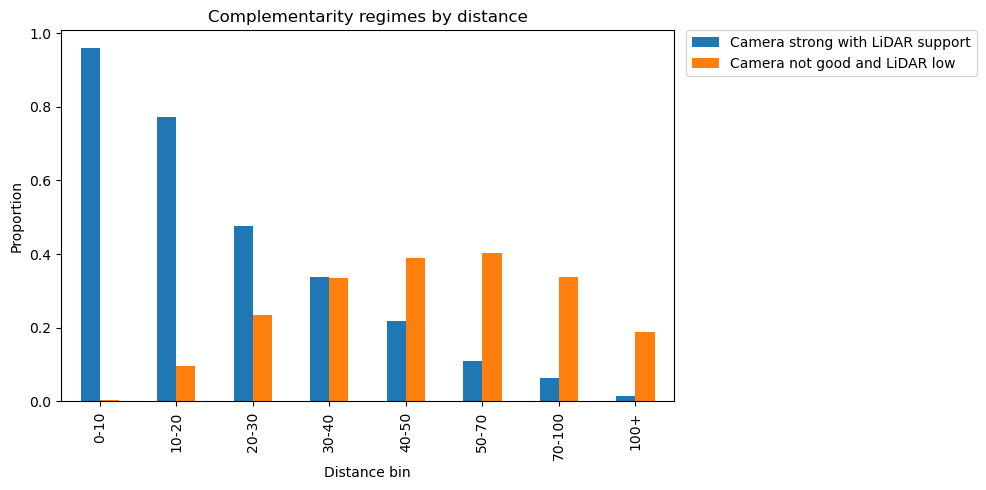

In [202]:
complementarity_by_distance = (
    eda_df.groupby("distance_bin")[complementarity_flags]
    .mean()
    .rename(columns=complementarity_label_map)
)

plot_grouped_flag_rates(
    table=complementarity_by_distance,
    title="Complementarity regimes by distance",
    xlabel="Distance bin",
    ylabel="Proportion",
    rot=90,
    # ha="right",
)

### Complementarity by visibility

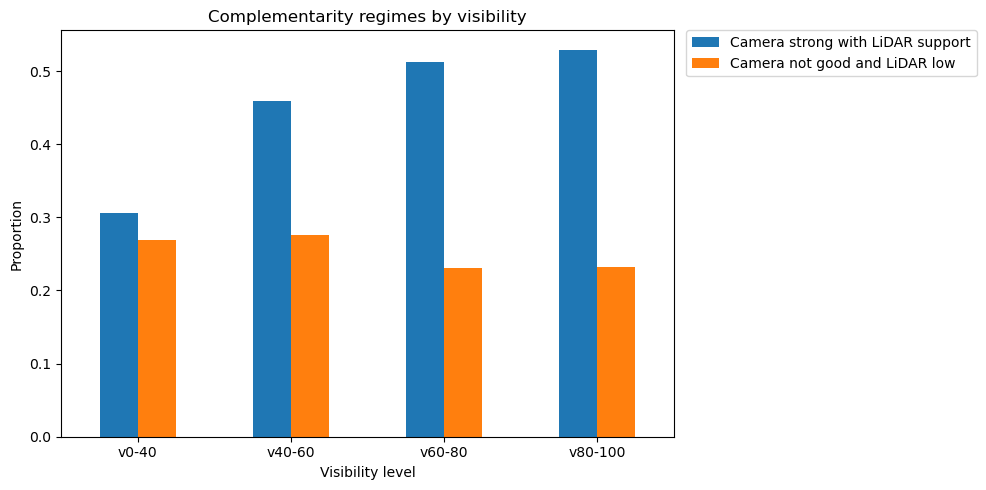

In [203]:
complementarity_by_visibility = (
    eda_df.groupby("visibility_level")[complementarity_flags]
    .mean()
    .rename(columns=complementarity_label_map)
)

plot_grouped_flag_rates(
    table=complementarity_by_visibility,
    title="Complementarity regimes by visibility",
    xlabel="Visibility level",
    ylabel="Proportion",
)

### Complementarity by category

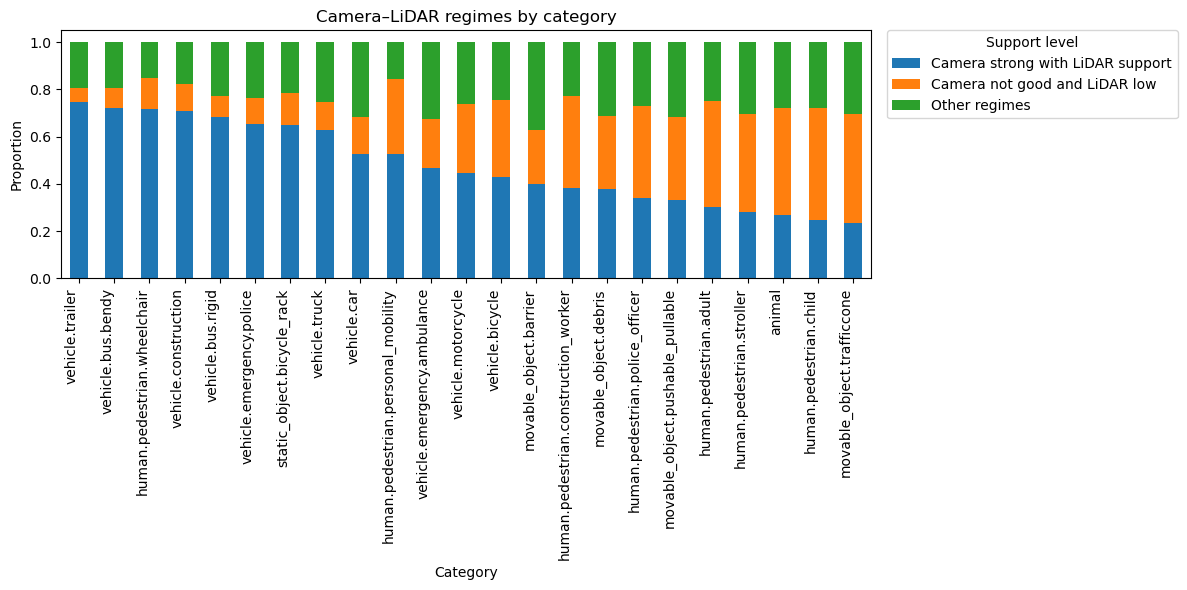

In [205]:
# ------------------------------------------------------------
# Camera–LiDAR regimes by category as one stacked bar plot
# ------------------------------------------------------------

cam_lidar_by_category = (
    eda_df.groupby("category_name")[
        [
            "camera_strong_with_lidar_support",
            "camera_not_good_lidar_low",
        ]
    ]
    .mean()
)

# Add remaining cases so the stacked bars sum to 1
cam_lidar_by_category["other_regimes"] = (
    1
    - cam_lidar_by_category[
        [
            "camera_strong_with_lidar_support",
            "camera_not_good_lidar_low",
        ]
    ].sum(axis=1)
)

# Rename columns for readability
cam_lidar_by_category = cam_lidar_by_category.rename(
    columns={
        "camera_strong_with_lidar_support": "Camera strong with LiDAR support",
        "camera_not_good_lidar_low": "Camera not good and LiDAR low",
        "other_regimes": "Other regimes",
    }
)

# Sort categories by one regime of interest
cam_lidar_by_category = cam_lidar_by_category.sort_values(
    by="Camera strong with LiDAR support",
    ascending=False
)

plot_stacked_proportion_table(
    table=cam_lidar_by_category,
    title="Camera–LiDAR regimes by category",
    xlabel="Category",
    ylabel="Proportion",
    figsize=(12, 6),
    rot=90,
    ha="right",
)

### Compact summary tables

In [109]:
print("\nComplementarity regimes by distance:")
display(complementarity_by_distance.round(3))

print("\nComplementarity regimes by visibility:")
display(complementarity_by_visibility.round(3))


Complementarity regimes by distance:


,Camera rescues weak range,Range rescues weak camera,Strong all modalities,Weak all modalities
distance_bin,,,,
0-10,0.025,0.014,0.159,0.001
10-20,0.099,0.007,0.171,0.035
20-30,0.139,0.027,0.109,0.140
30-40,0.196,0.031,0.055,0.258
40-50,0.162,0.042,0.033,0.350
50-70,0.057,0.056,0.021,0.446
70-100,0.046,0.060,0.006,0.588
100+,0.016,0.054,0.000,0.801



Complementarity regimes by visibility:


,Camera rescues weak range,Range rescues weak camera,Strong all modalities,Weak all modalities
visibility_level,,,,
v0-40,0.243,0.015,0.020,0.285
v40-60,0.142,0.024,0.054,0.201
v60-80,0.094,0.029,0.094,0.178
v80-100,0.039,0.040,0.141,0.197


### Observations

- To complete after validating the final plots and summary tables.
- Key points to summarize:
  - where camera remains useful while range sensing is weak
  - where LiDAR or radar remain useful when camera is weak
  - whether complementarity depends more strongly on distance, visibility, or category
  - which categories most clearly motivate fusion

**Conclusion template:**  
Overall, cross-modal complementarity is concentrated in specific regimes where one modality remains informative while another weakens, supporting the need for fusion strategies that adapt to distance, visibility, and object class.


- To complete after validating the final plots and summary tables.
- Key points to summarize:
  - where camera compensates for weak or missing range sensing
  - where LiDAR or radar compensate for weak camera conditions
  - how complementarity varies with distance and visibility
  - which object categories most strongly benefit from multi-sensor fusion

**Conclusion template:**  
Overall, cross-modal complementarity is concentrated in specific regimes where one modality remains informative while another weakens, supporting the need for fusion strategies that adapt to distance, visibility, and object class.

# Machine learning

## Machine Learning Research Question
In this Jupyter notebook, I build a supervised 3D object detection pipeline on nuScenes by preparing inputs and targets directly from the official tables. For each sample (one timestamp in the sample table), I assemble the model input by collecting the linked sensor records in sample_data: the LiDAR point cloud file (LIDAR_TOP), the six camera image files (CAM_), and optionally the radar point cloud files (RADAR_). I use calibrated_sensor and ego_pose to transform all sensor measurements into a consistent coordinate frame (ego or global) and to align modalities spatially and temporally. I prepare the ground-truth output for each sample from sample_annotation by extracting category_name and the 3D bounding box parameters (translation, size, rotation) and the object velocity, forming a per-sample set of labeled 3D boxes. With these prepared inputs and outputs, I run a controlled ablation where the only change is which sample_data modalities are included (LiDAR-only, camera+LiDAR, camera+LiDAR+radar) and evaluate each variant using the official nuScenes metrics NDS, mAP, and AVE, followed by a short error breakdown by object class and distance.

## Planned Models and Rationale

## Detailed Machine Learning Strategy

# Key findings and conclusions